In [ ]:
import os
import sys
from pathlib import Path

import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str((repo_root / "src").resolve()))

from airquality.data.utils import get_longest_segment, load_dataset_paths, load_to_df
from airquality.modeling.training import build_train_val_test_series, train_global_methods

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

/home/daniel/pollution/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


'0'

In [2]:
file_paths = load_dataset_paths("../Datos-post-COUTA/*/", key_word="NO2", file_extension="csv")

proc_ds = list() 

for path in file_paths:
    proc_ds.append(load_to_df(path))

longest_segment = get_longest_segment(proc_ds, False)

--- Winning Segment ---
Dimensions: 215 rows x 7 columns
Recovered columns: ['Aquatec - Calle Real', 'AQN1 - Puerto', 'Aquatec - Ramon y Cajal', 'Aquatec - Pintor Balaca', 'Aquatec - Carlos III', 'Aquatec - San Diego', 'AQN2 - San Francisco']
Range: 2024-03-19 15:00:00 to 2024-03-28 13:00:00
Score (Total area): 27.544456535888802
------------------------


In [ ]:
size_k = 5

dataset_bundle = build_train_val_test_series(proc_ds, longest_segment, val_size=48, min_train_len=72+size_k)

methods_to_run = ["TiDE"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando TiDE


number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 1, `temporal_width_past=1`.
Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 5: 100%|██████████| 429/429 [00:11<00:00, 35.94it/s, train_loss=0.0716, val_loss=0.377]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/TiDE_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["NHiTS"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando NHiTS


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 5: 100%|██████████| 429/429 [00:19<00:00, 22.32it/s, train_loss=0.0556, val_loss=0.383]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/NHiTS_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["TCN"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando TCN


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 30: 100%|██████████| 429/429 [00:09<00:00, 44.54it/s, train_loss=0.425, val_loss=0.456]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/TCN_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["TSMixer"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando TSMixer


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 7: 100%|██████████| 429/429 [00:12<00:00, 34.78it/s, train_loss=0.221, val_loss=0.362]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/TSMixer_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["RNN"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando RNN


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 33: 100%|██████████| 429/429 [00:08<00:00, 53.37it/s, train_loss=0.0603, val_loss=0.146]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/RNN_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["NLinear"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando NLinear


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 5: 100%|██████████| 429/429 [00:05<00:00, 75.94it/s, train_loss=0.243, val_loss=0.338]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/NLinear_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [ ]:
methods_to_run = ["DLinear"]
trained_models = train_global_methods(dataset_bundle, size_k=size_k, method_names=methods_to_run)

Entrenando DLinear


Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.


Epoch 5: 100%|██████████| 429/429 [00:05<00:00, 73.97it/s, train_loss=0.262, val_loss=0.342]
Modelo guardado en: /home/daniel/pollution/src/artifacts/models/DLinear_k5.pt
CSV exportado en: /home/daniel/pollution/src/artifacts/training_curves_and_times.csv


In [12]:
from pathlib import Path
import pickle

ARTIFACTS_DIR = Path("artifacts")
MODELS_DIR = ARTIFACTS_DIR / "models"
SCALERS_PATH = ARTIFACTS_DIR / "scalers.pkl"

MODELS_DIR.mkdir(parents=True, exist_ok=True)


def save_artifacts(trained_models: dict, dict_scalers: dict, size_k: int):
    for name, model in trained_models.items():
        model_path = MODELS_DIR / f"{name}_k{size_k}.pt"
        model.save(str(model_path))

    with open(SCALERS_PATH, "wb") as f:
        pickle.dump(dict_scalers, f)


def load_model(name: str, size_k: int, model_cls):
    model_path = MODELS_DIR / f"{name}_k{size_k}.pt"
    if not model_path.exists():
        return None
    return model_cls.load(str(model_path), map_location="cpu", pl_trainer_kwargs={"accelerator": "cpu"})


def load_scalers():
    if not SCALERS_PATH.exists():
        return None
    with open(SCALERS_PATH, "rb") as f:
        return pickle.load(f)

In [10]:
from darts.models import (
    DLinearModel,
    NHiTSModel,
    NLinearModel,
    RNNModel,
    TCNModel,
    TSMixerModel,
    TiDEModel,
)

In [16]:
trained_models = dict()
methods_to_run = ["TiDE", "NHiTS", "TCN", "TSMixer", "RNN", "NLinear", "DLinear"]
for name, model in zip(methods_to_run, [TiDEModel, NHiTSModel, TCNModel, TSMixerModel, RNNModel, NLinearModel, DLinearModel]):
    trained_models[name] = load_model(name, 5, model)

In [16]:
from scipy.stats import friedmanchisquare

# Crear matriz método x escenario
pivot = (
    df_benchmark
    .groupby(['Method','Series','Size_K'])['RMSE']
    .mean()
    .reset_index()
    .pivot_table(index=['Series','Size_K'],
                 columns='Method',
                 values='RMSE')
)

friedmanchisquare(*[pivot[col] for col in pivot.columns])# Si el p-valor < 0.05 existen diferencias significativas.

FriedmanchisquareResult(statistic=np.float64(94.85714285714278), pvalue=np.float64(6.399092741458015e-19))

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / "src").resolve()))
from airquality.imputation.run_benchmark import run_imputation_benchmark_parallel
results_df, ranking_df, plot_store = run_imputation_benchmark_parallel(
    size_k=5,
    model_names=("TiDE", "NHiTS", "TCN", "TSMixer", "RNN", "NLinear", "DLinear", "TSPulse"),
    force_cpu=True,
    gap_sizes=(2, 5),
    num_gaps=15,
    gap_strategy="hybrid_tspulse",
    metrics=("mae", "rmse", "mase"),
    random_seed=42,
    max_workers=4,
)

[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=5: 41 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=5: 41 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo i

In [5]:
display(results_df.head())
display(ranking_df)

,Modelo,Serie,Gap_Size,MAE,RMSE,MASE
0,TiDE,AQN1 - Puerto,2,1.029562,1.441914,0.928202
1,TiDE,AQN2 - San Francisco,2,2.564083,3.388744,0.804498
2,TiDE,Aquatec - Calle Real,2,4.269781,5.820127,0.743308
3,TiDE,Aquatec - Carlos III,2,1.326181,1.715140,0.513774
4,TiDE,Aquatec - Pintor Balaca,2,1.409480,2.012757,0.573704


,Modelo,MAE,RMSE,MASE
0,TSPulse,0.886595,1.615741,0.282236
1,NLinear,1.703536,2.463014,0.627243
2,DLinear,1.792448,2.528379,0.668532
3,NHiTS,2.037002,2.978535,0.678406
4,TiDE,2.080046,2.961551,0.723110
5,RNN,2.164714,3.226150,0.750302
6,TSMixer,2.170757,2.985048,0.909649
7,TCN,2.892604,4.279959,0.934010


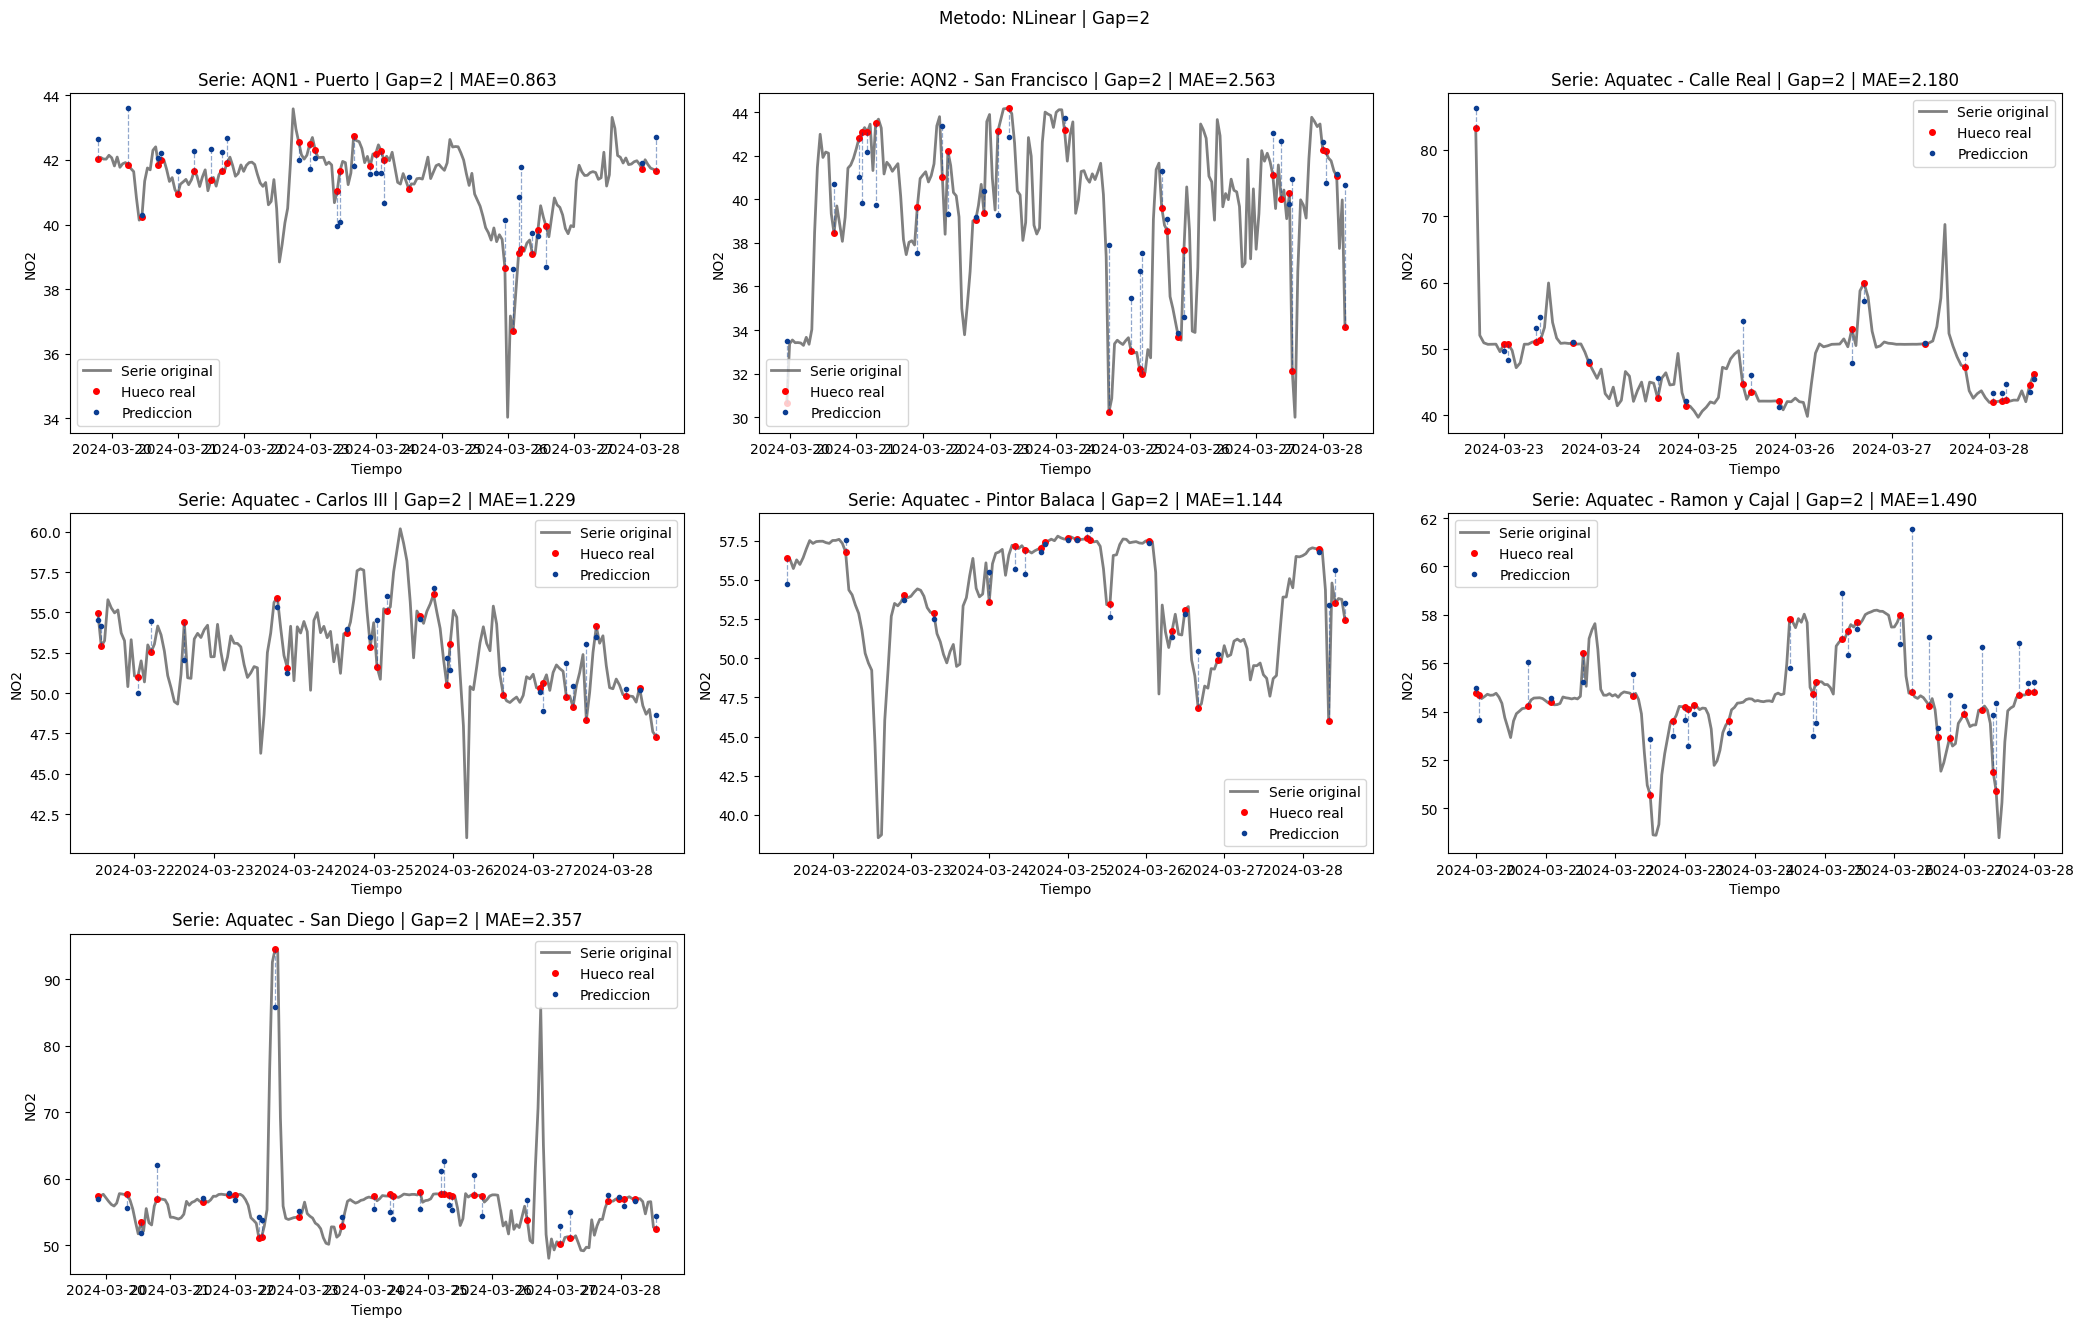

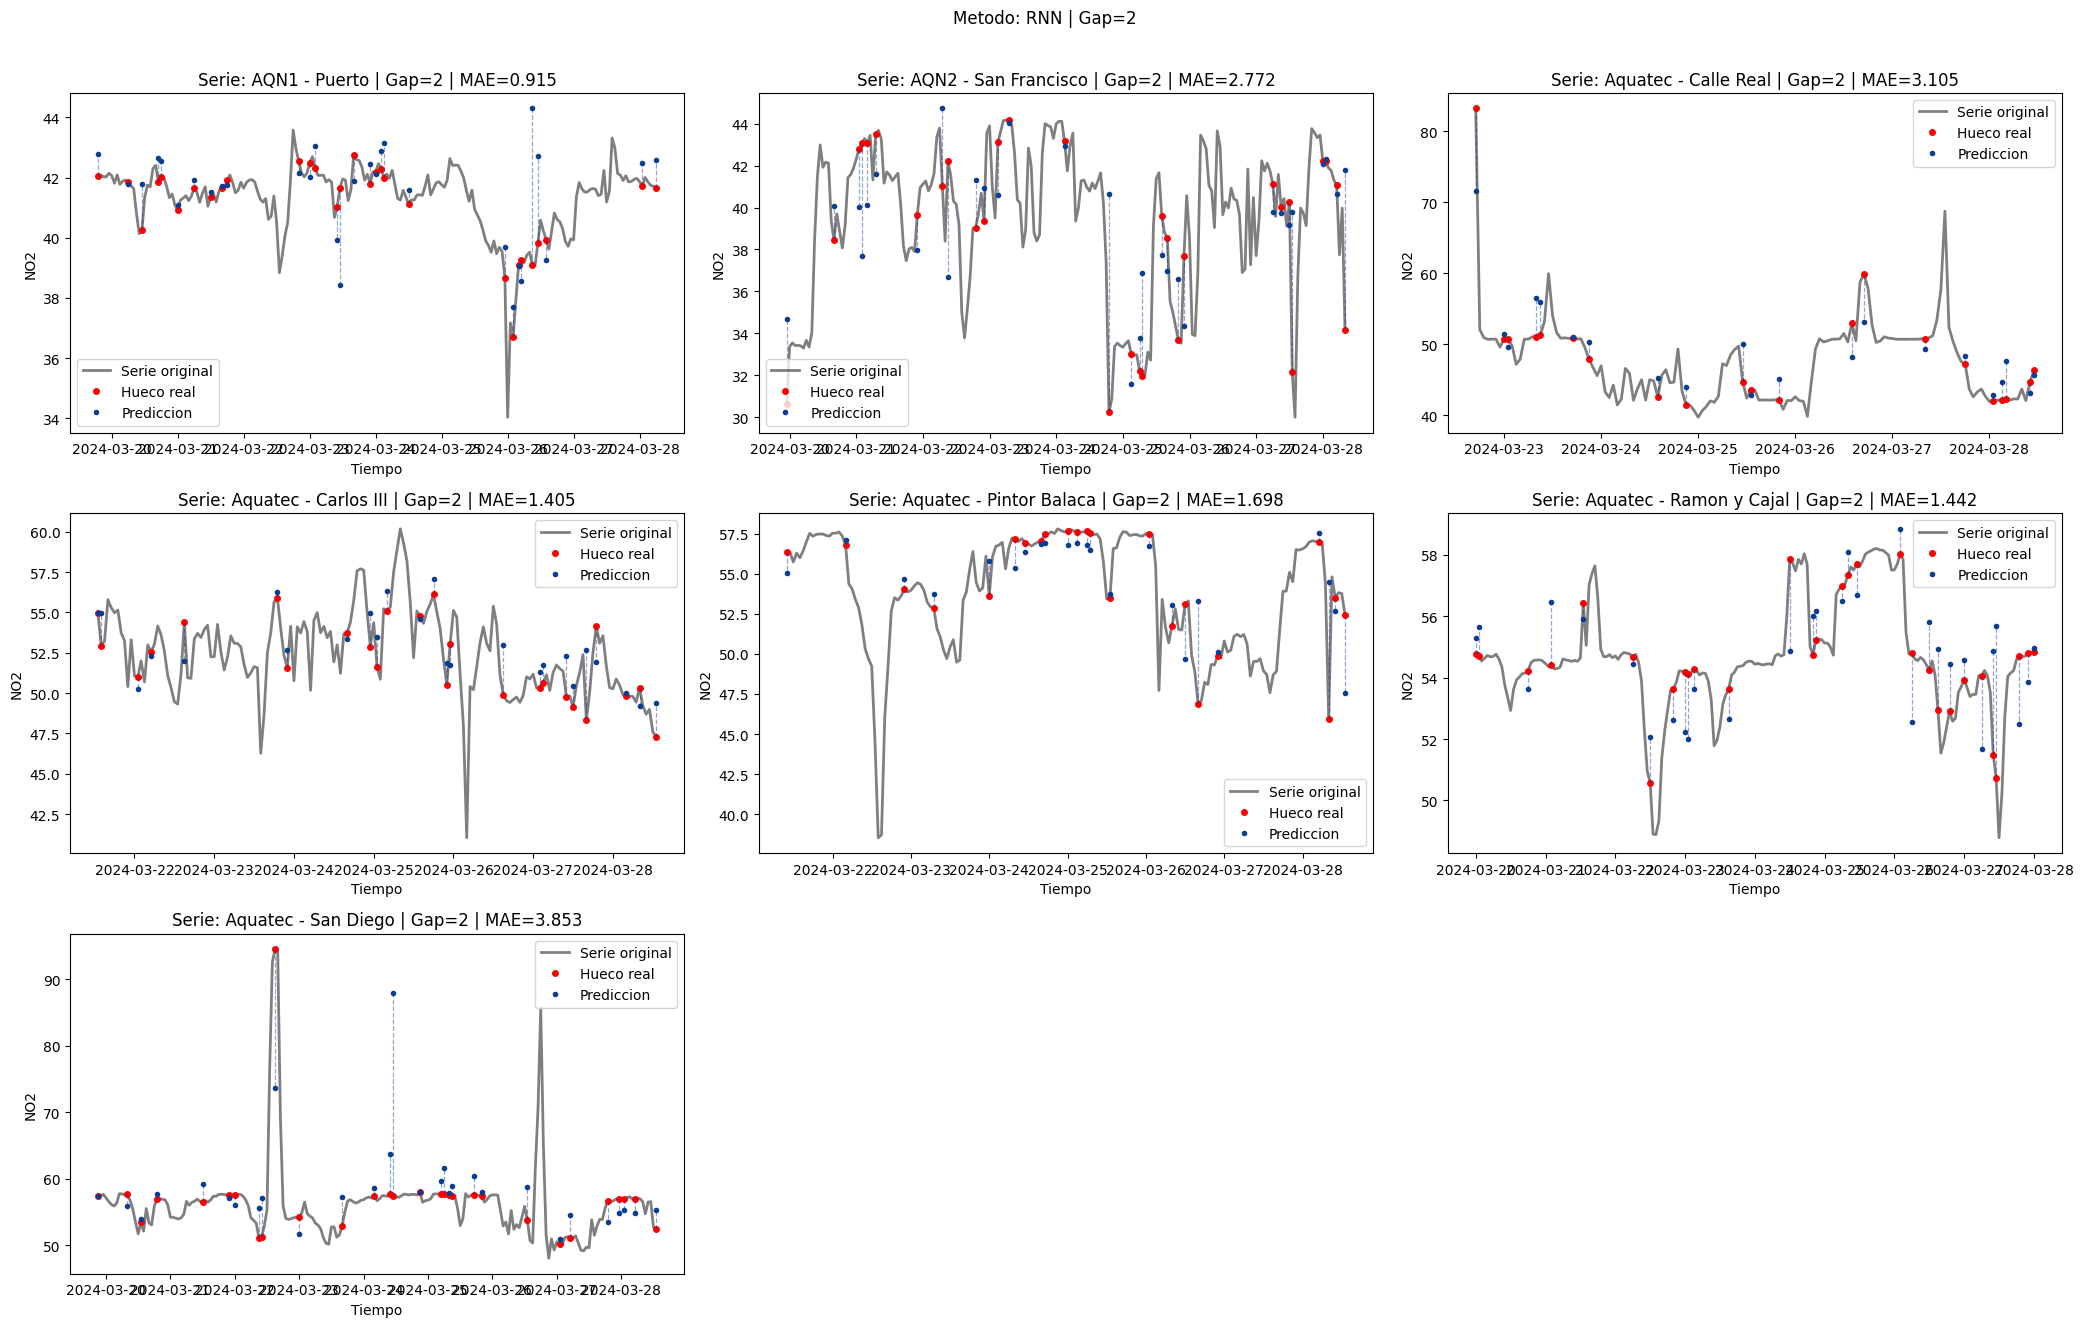

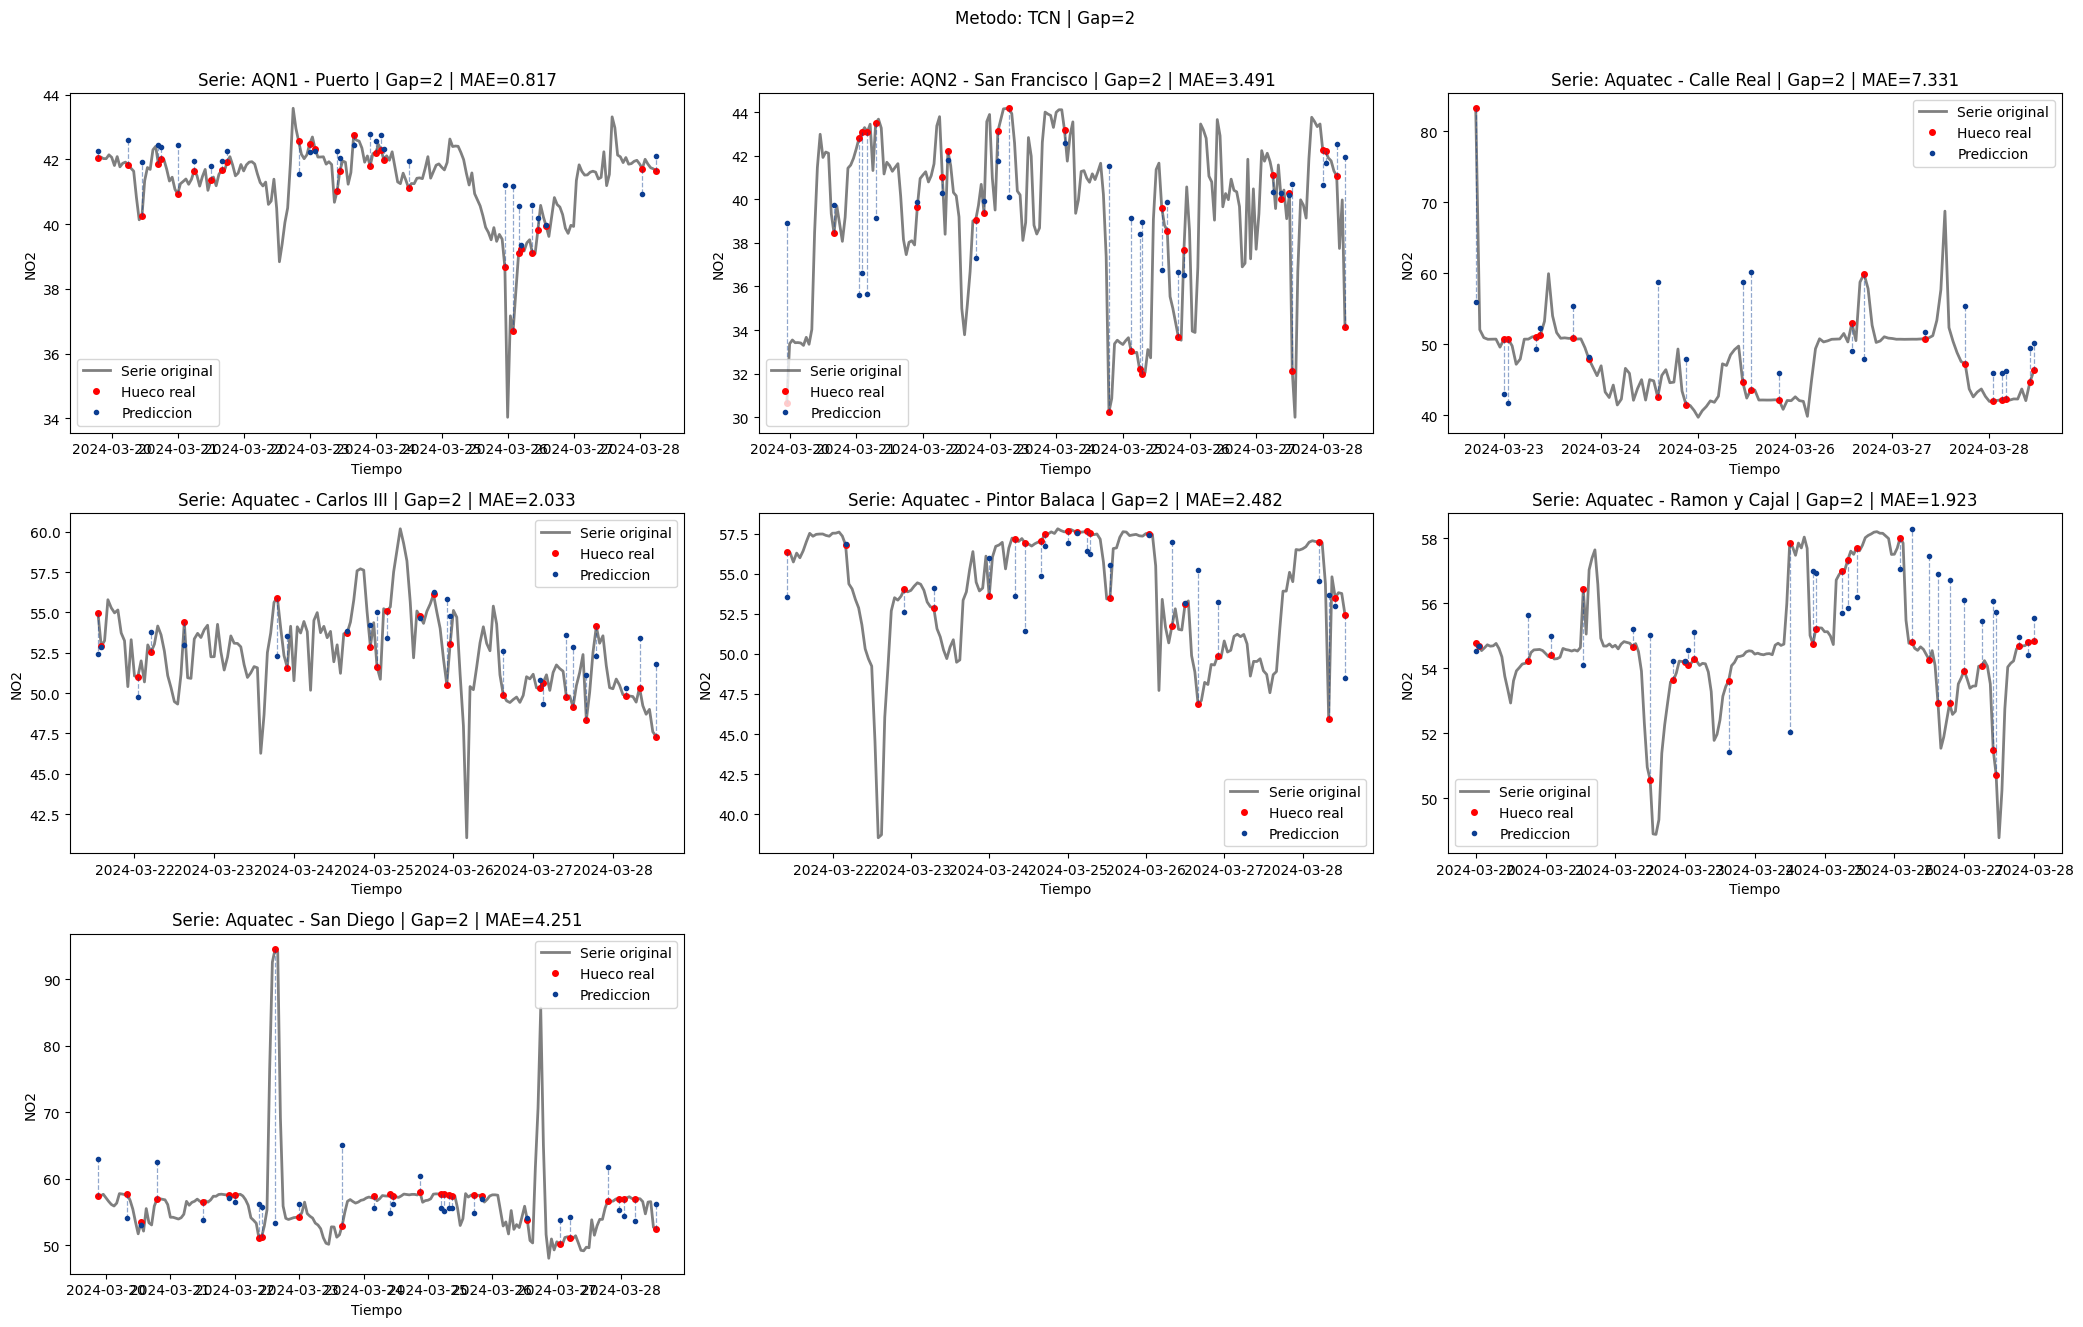

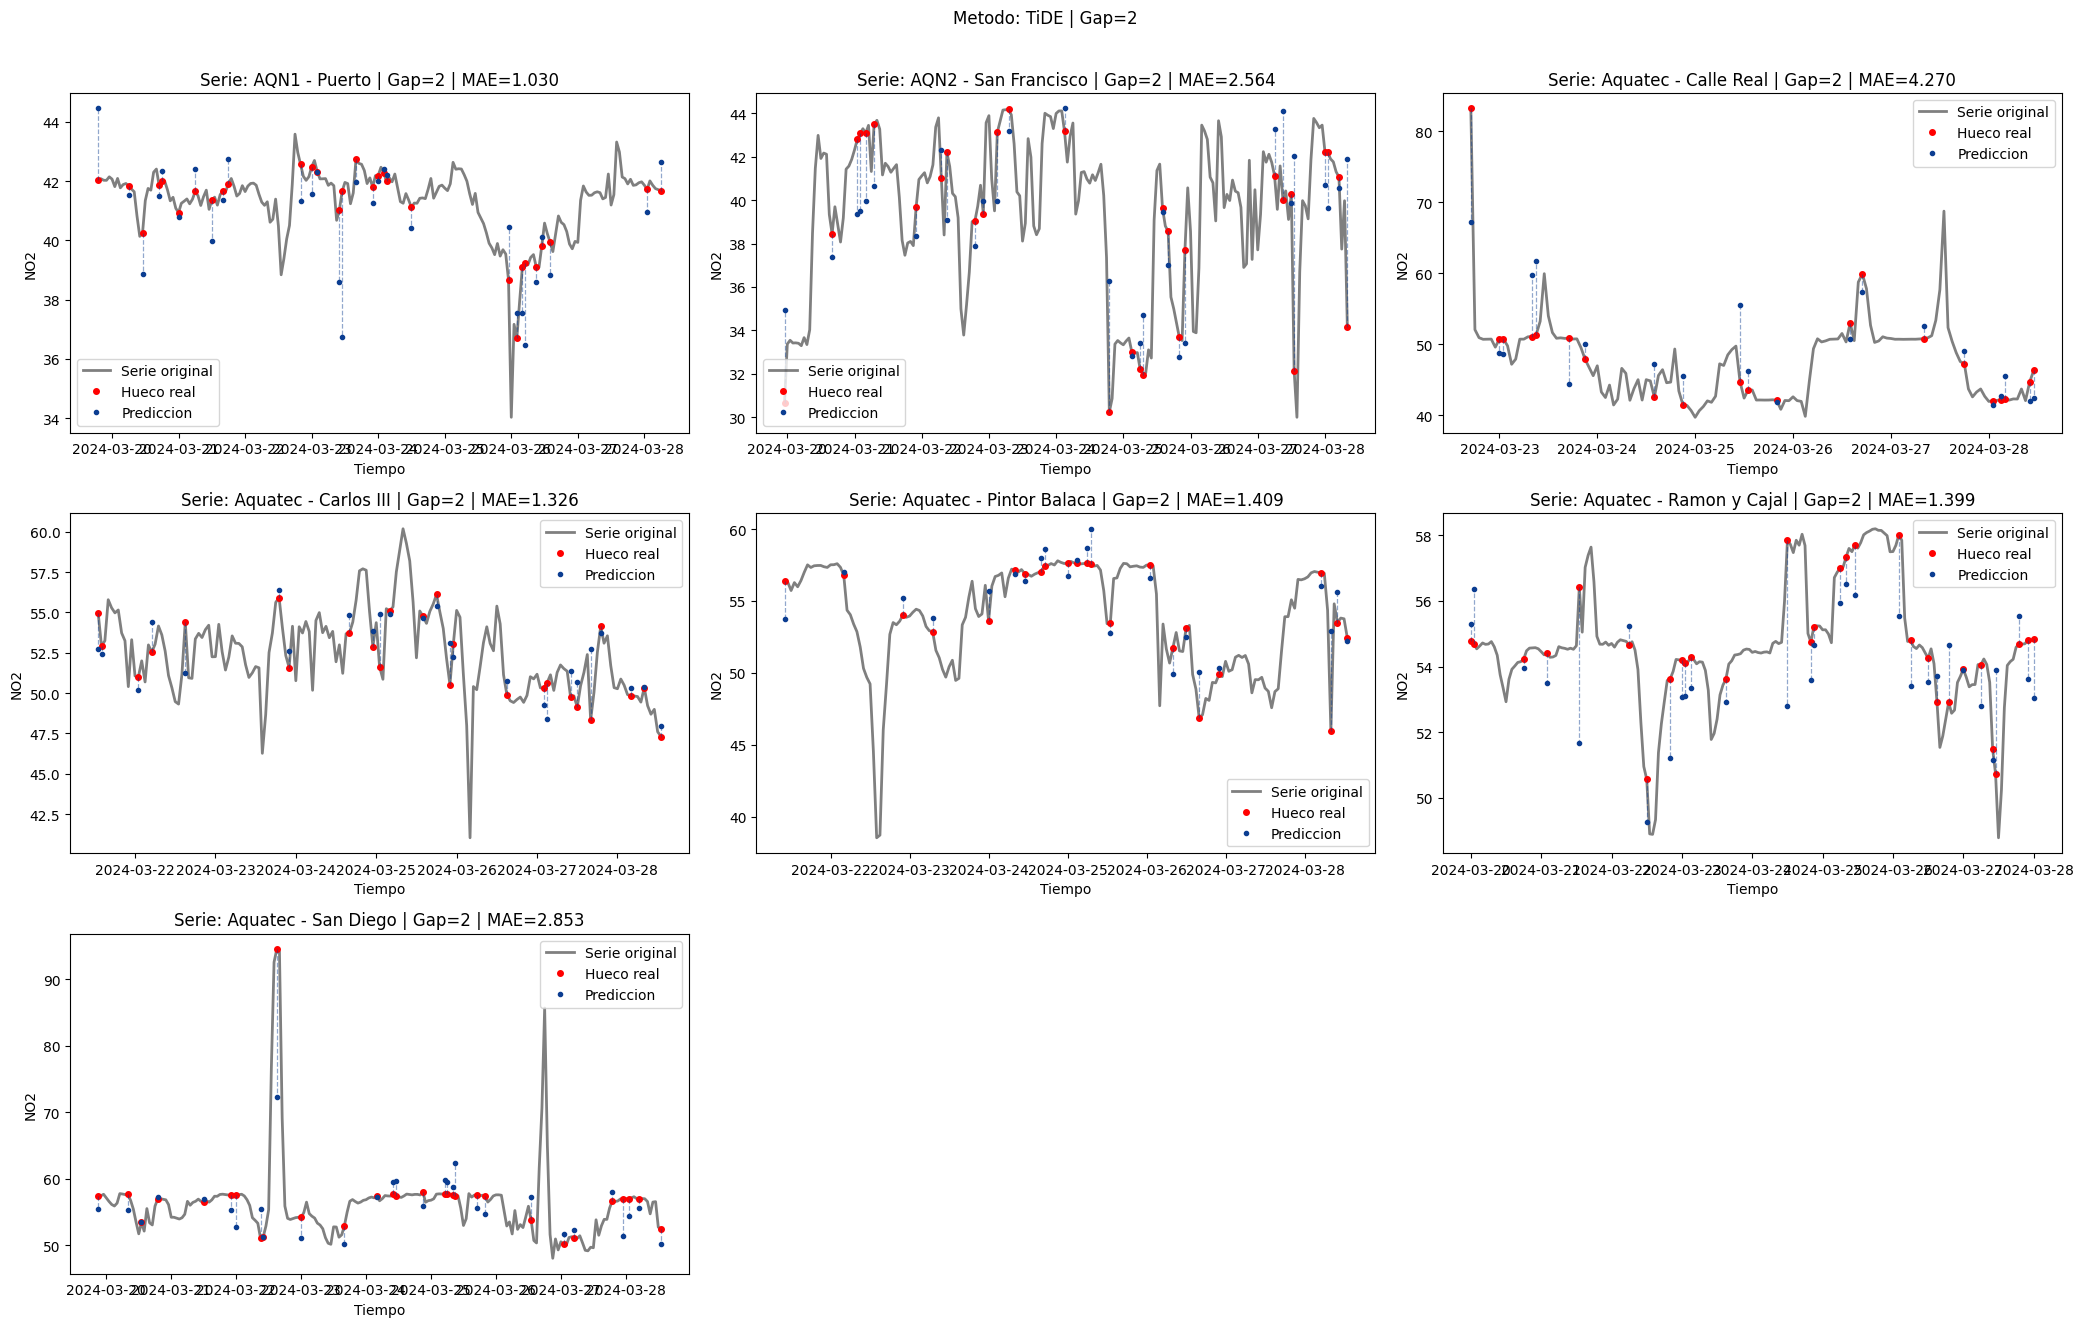

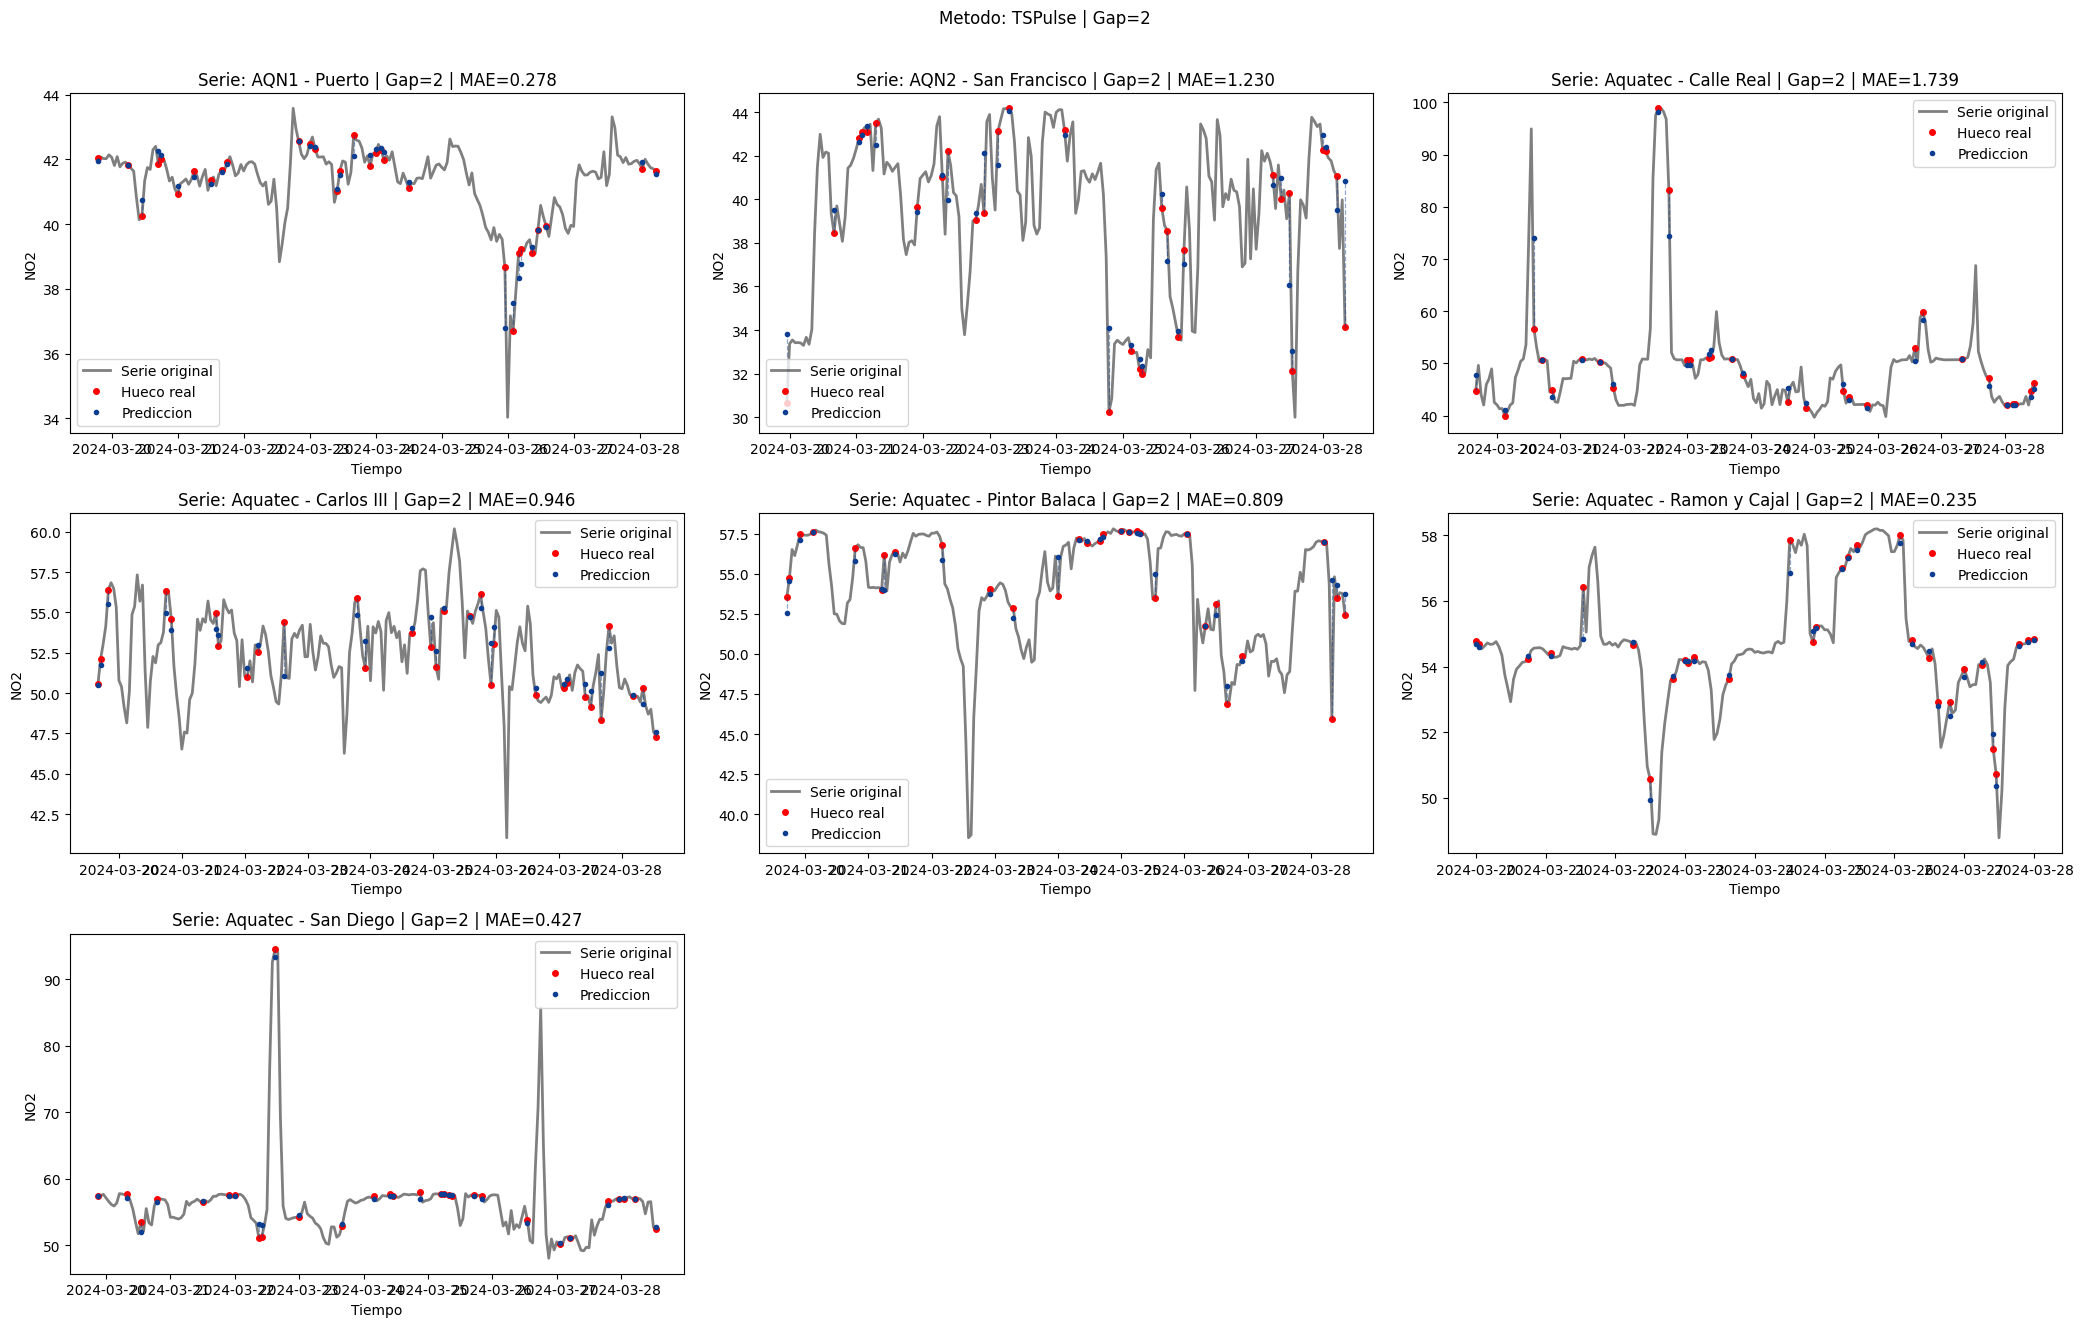

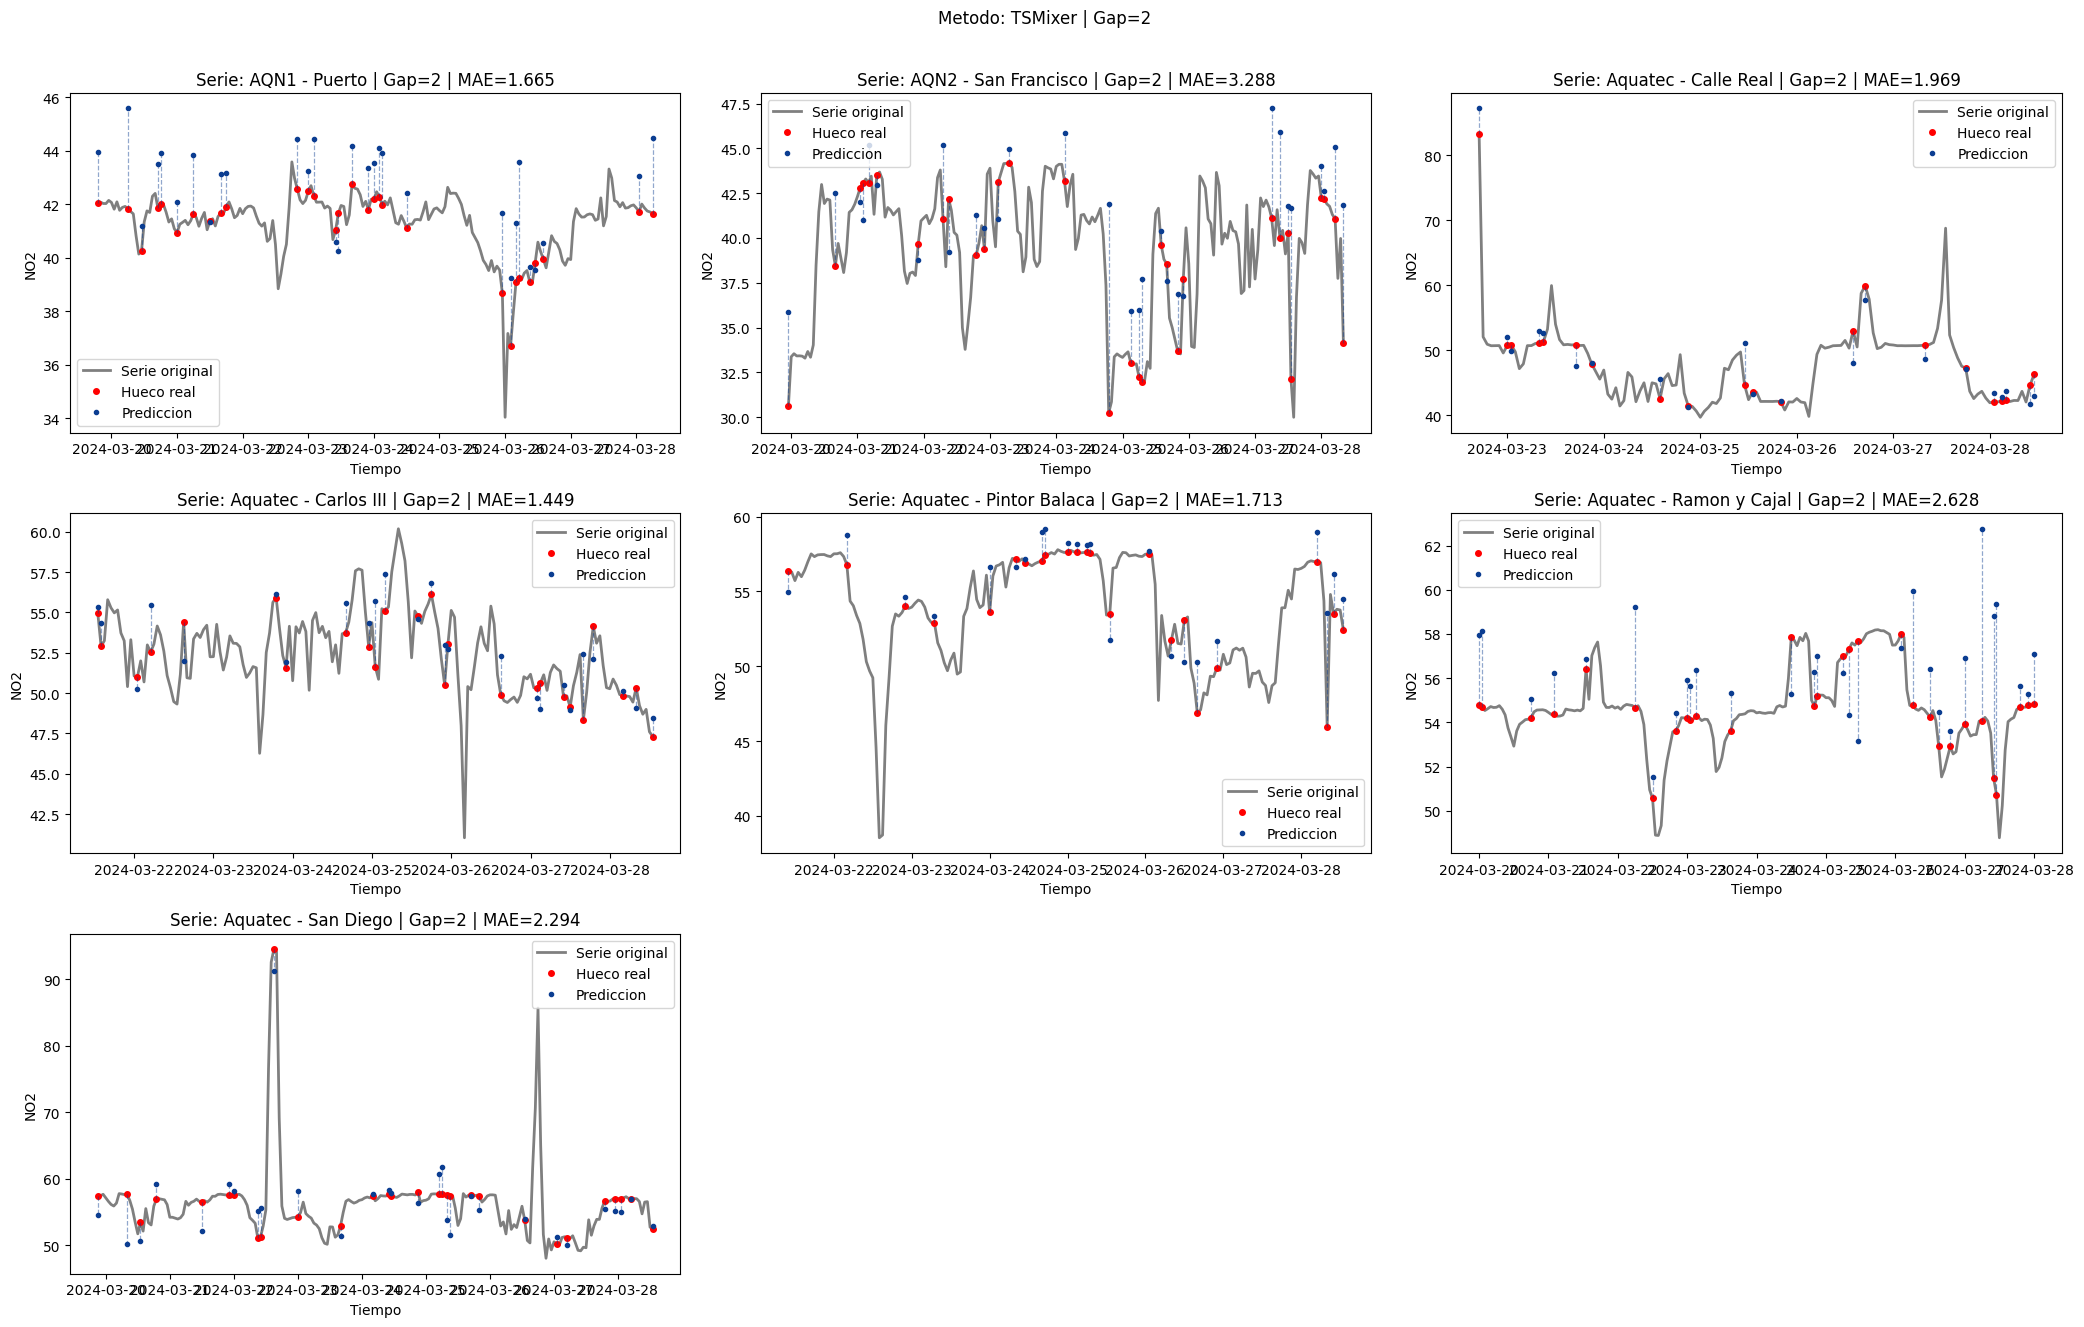

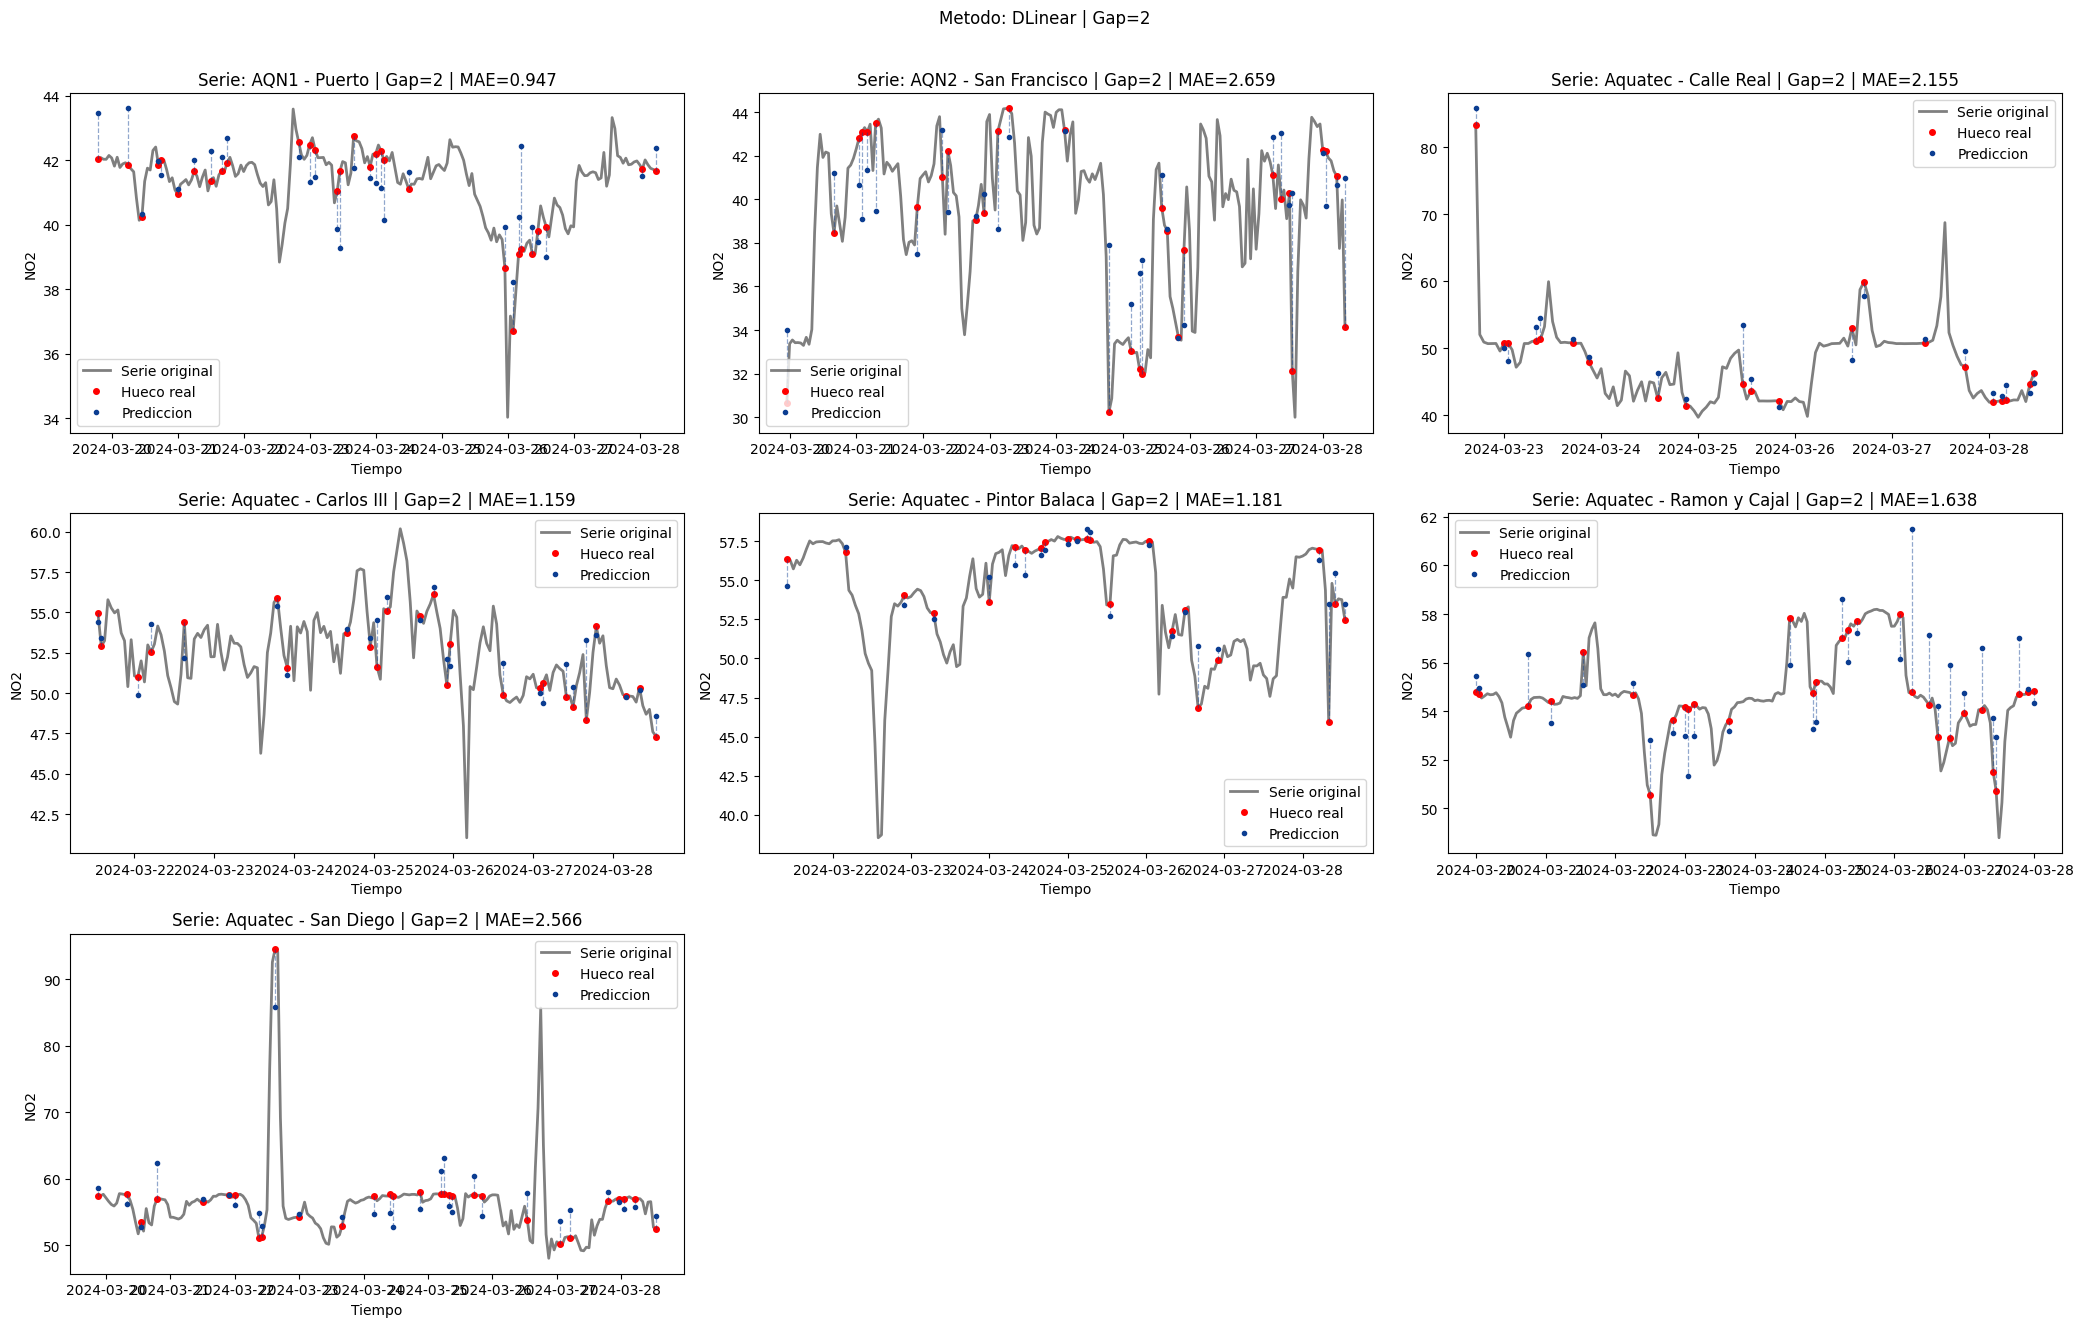

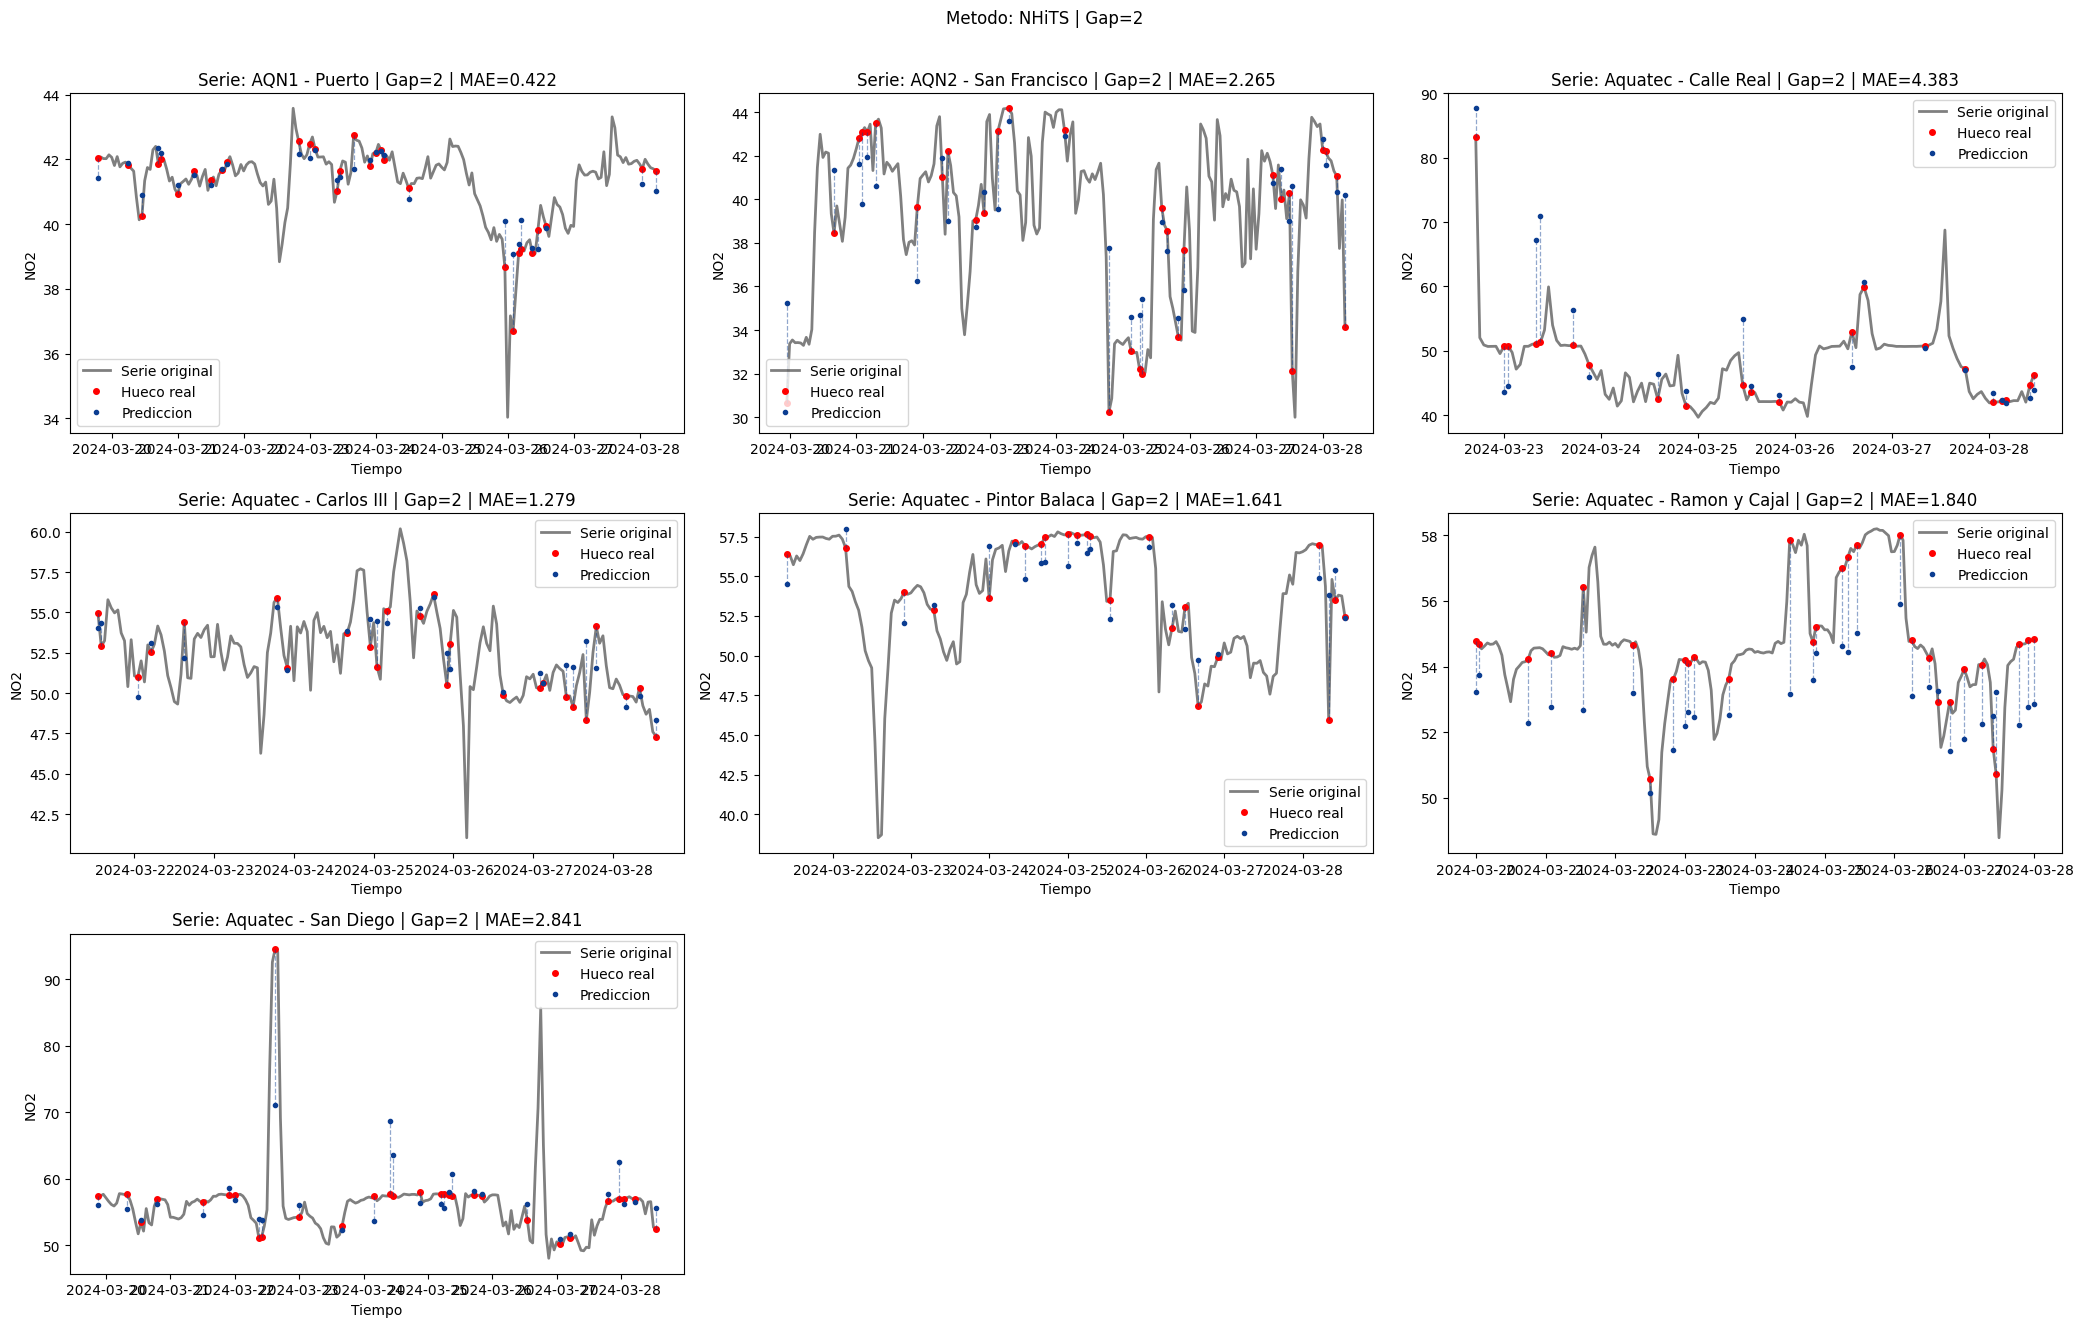

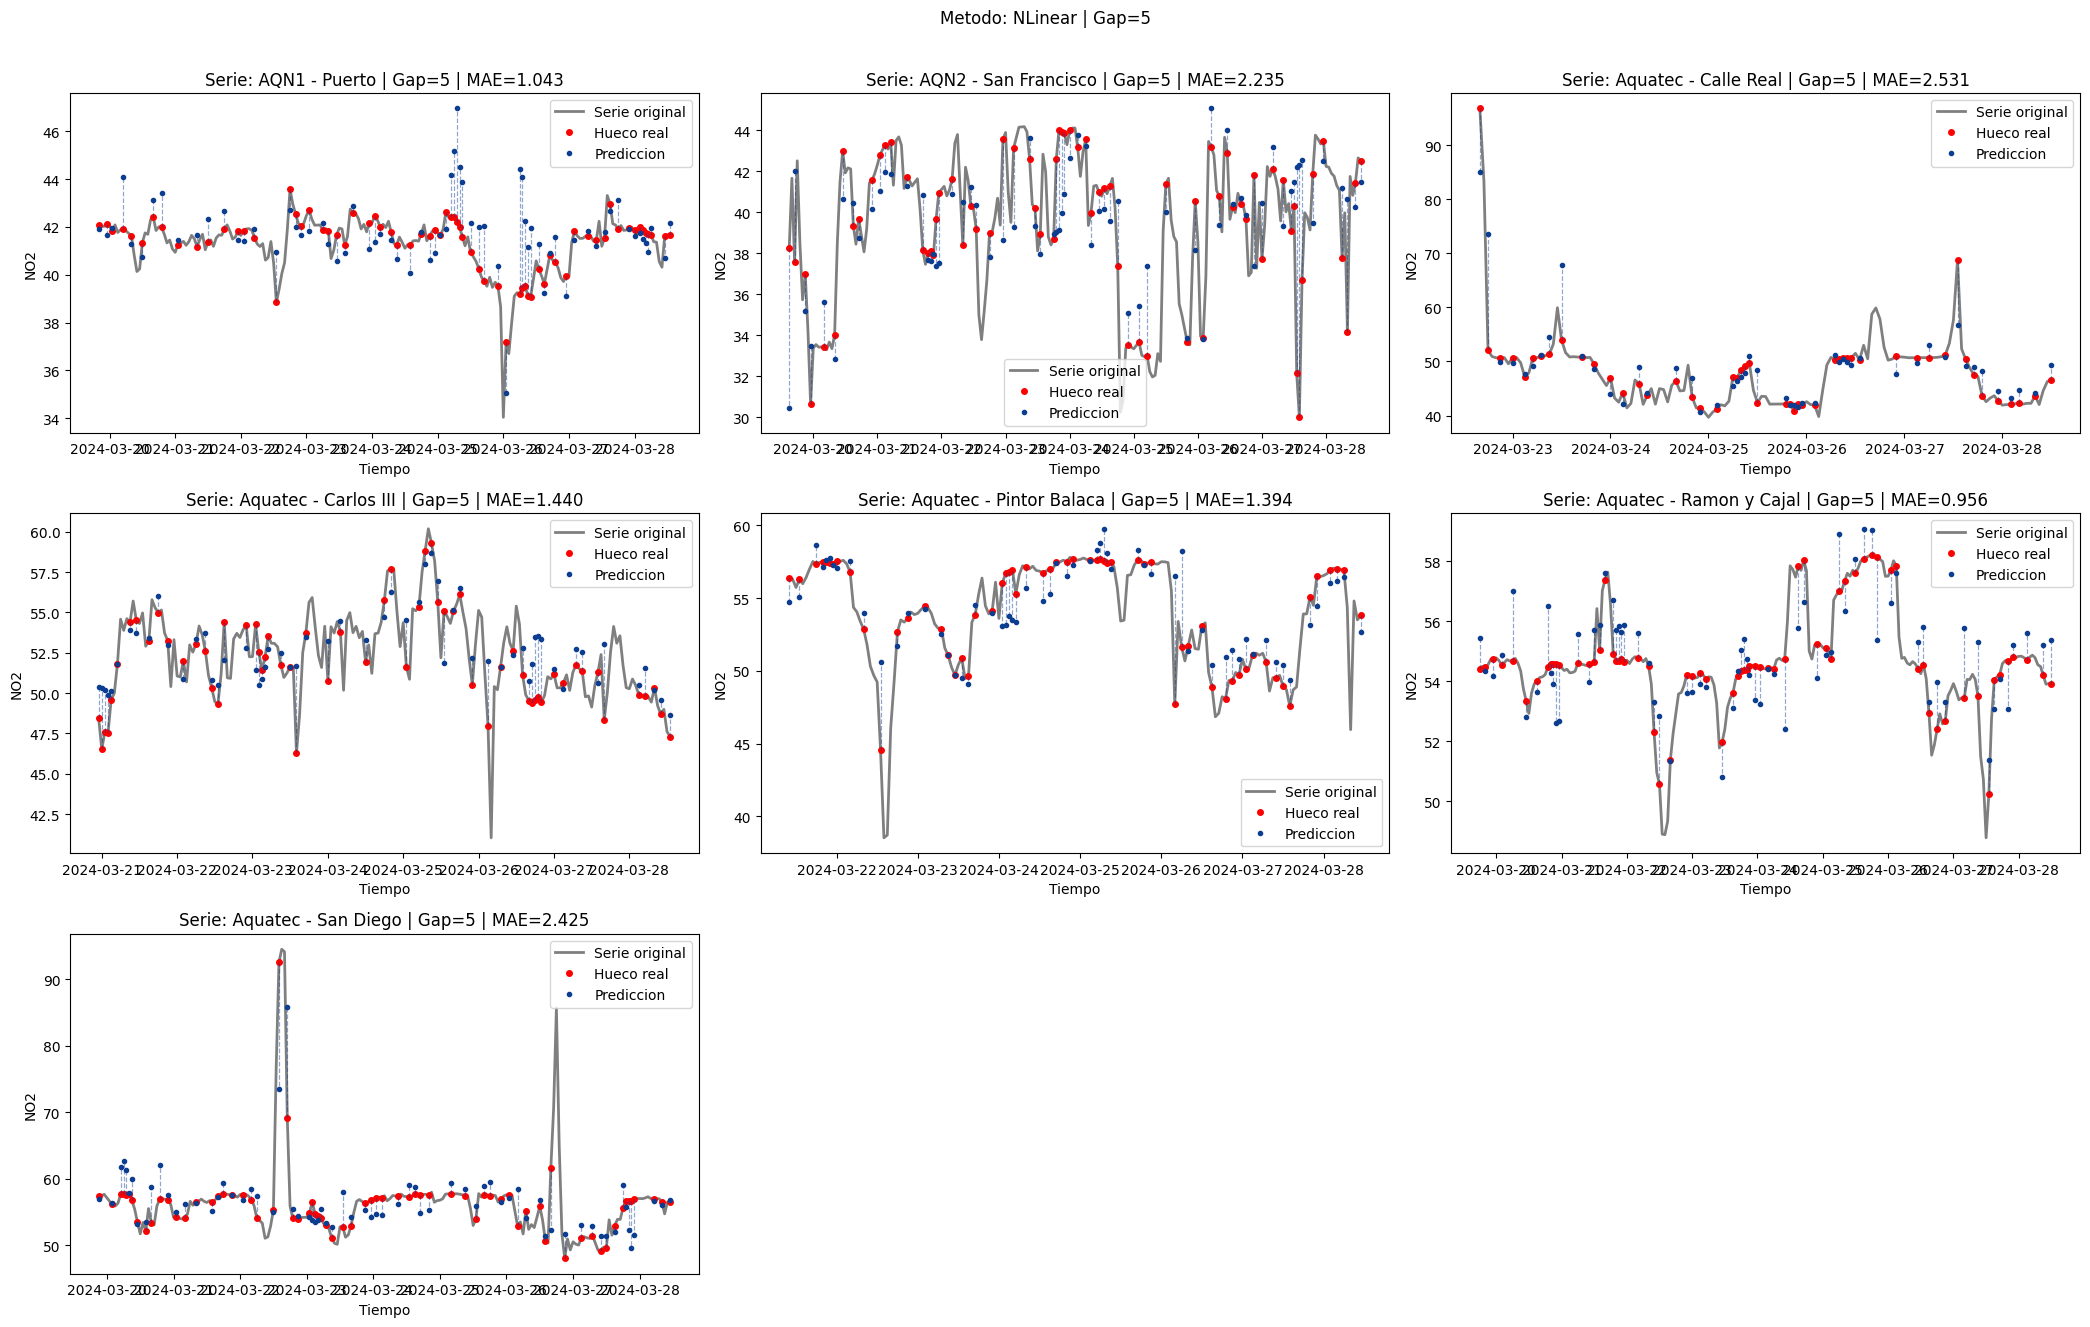

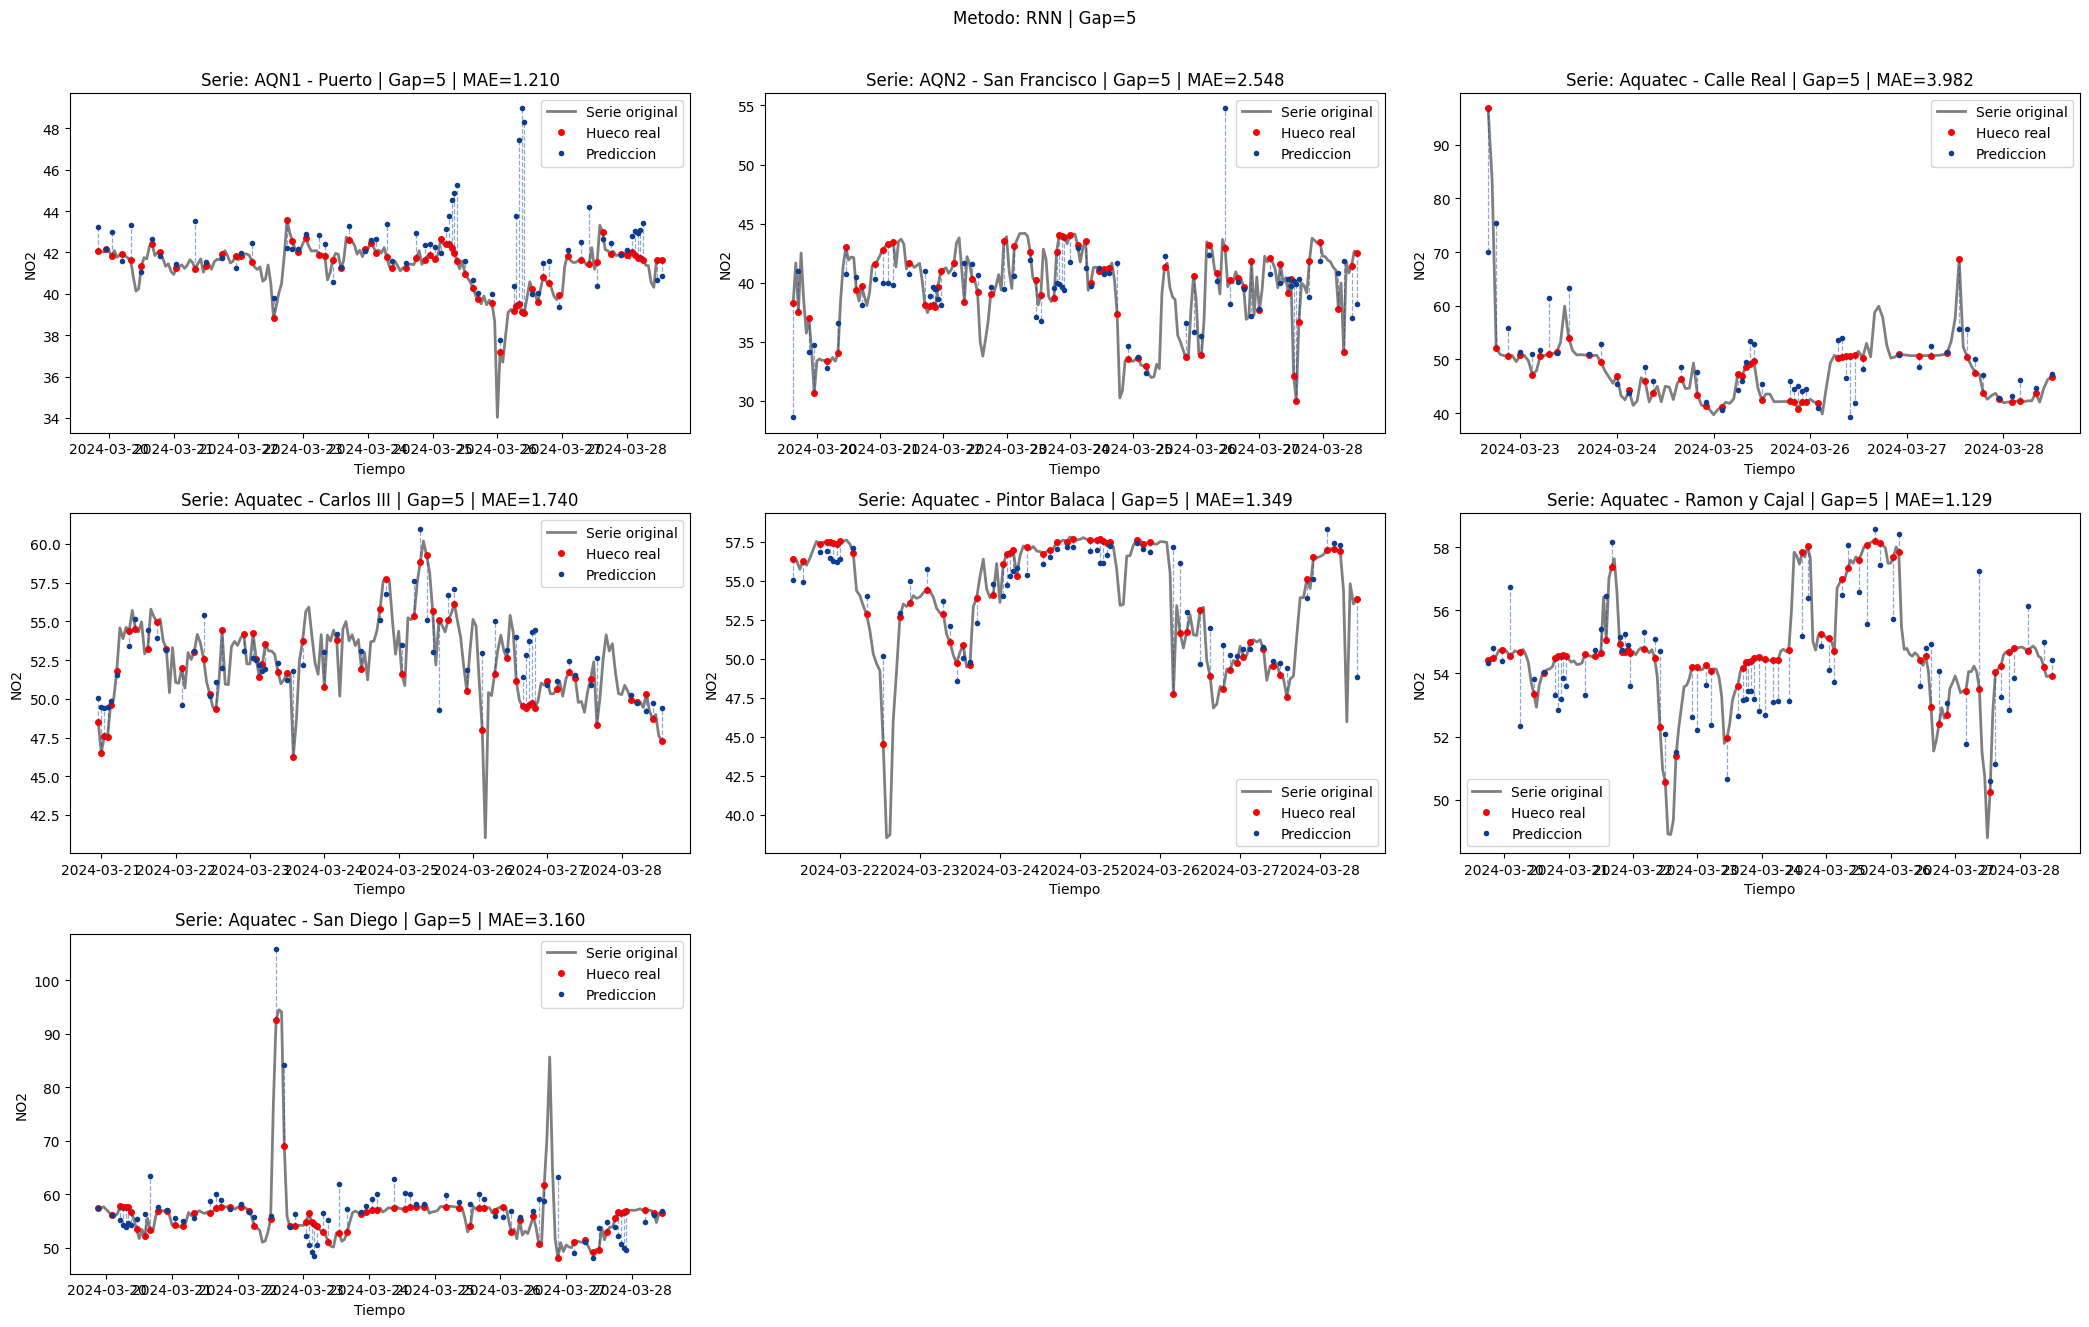

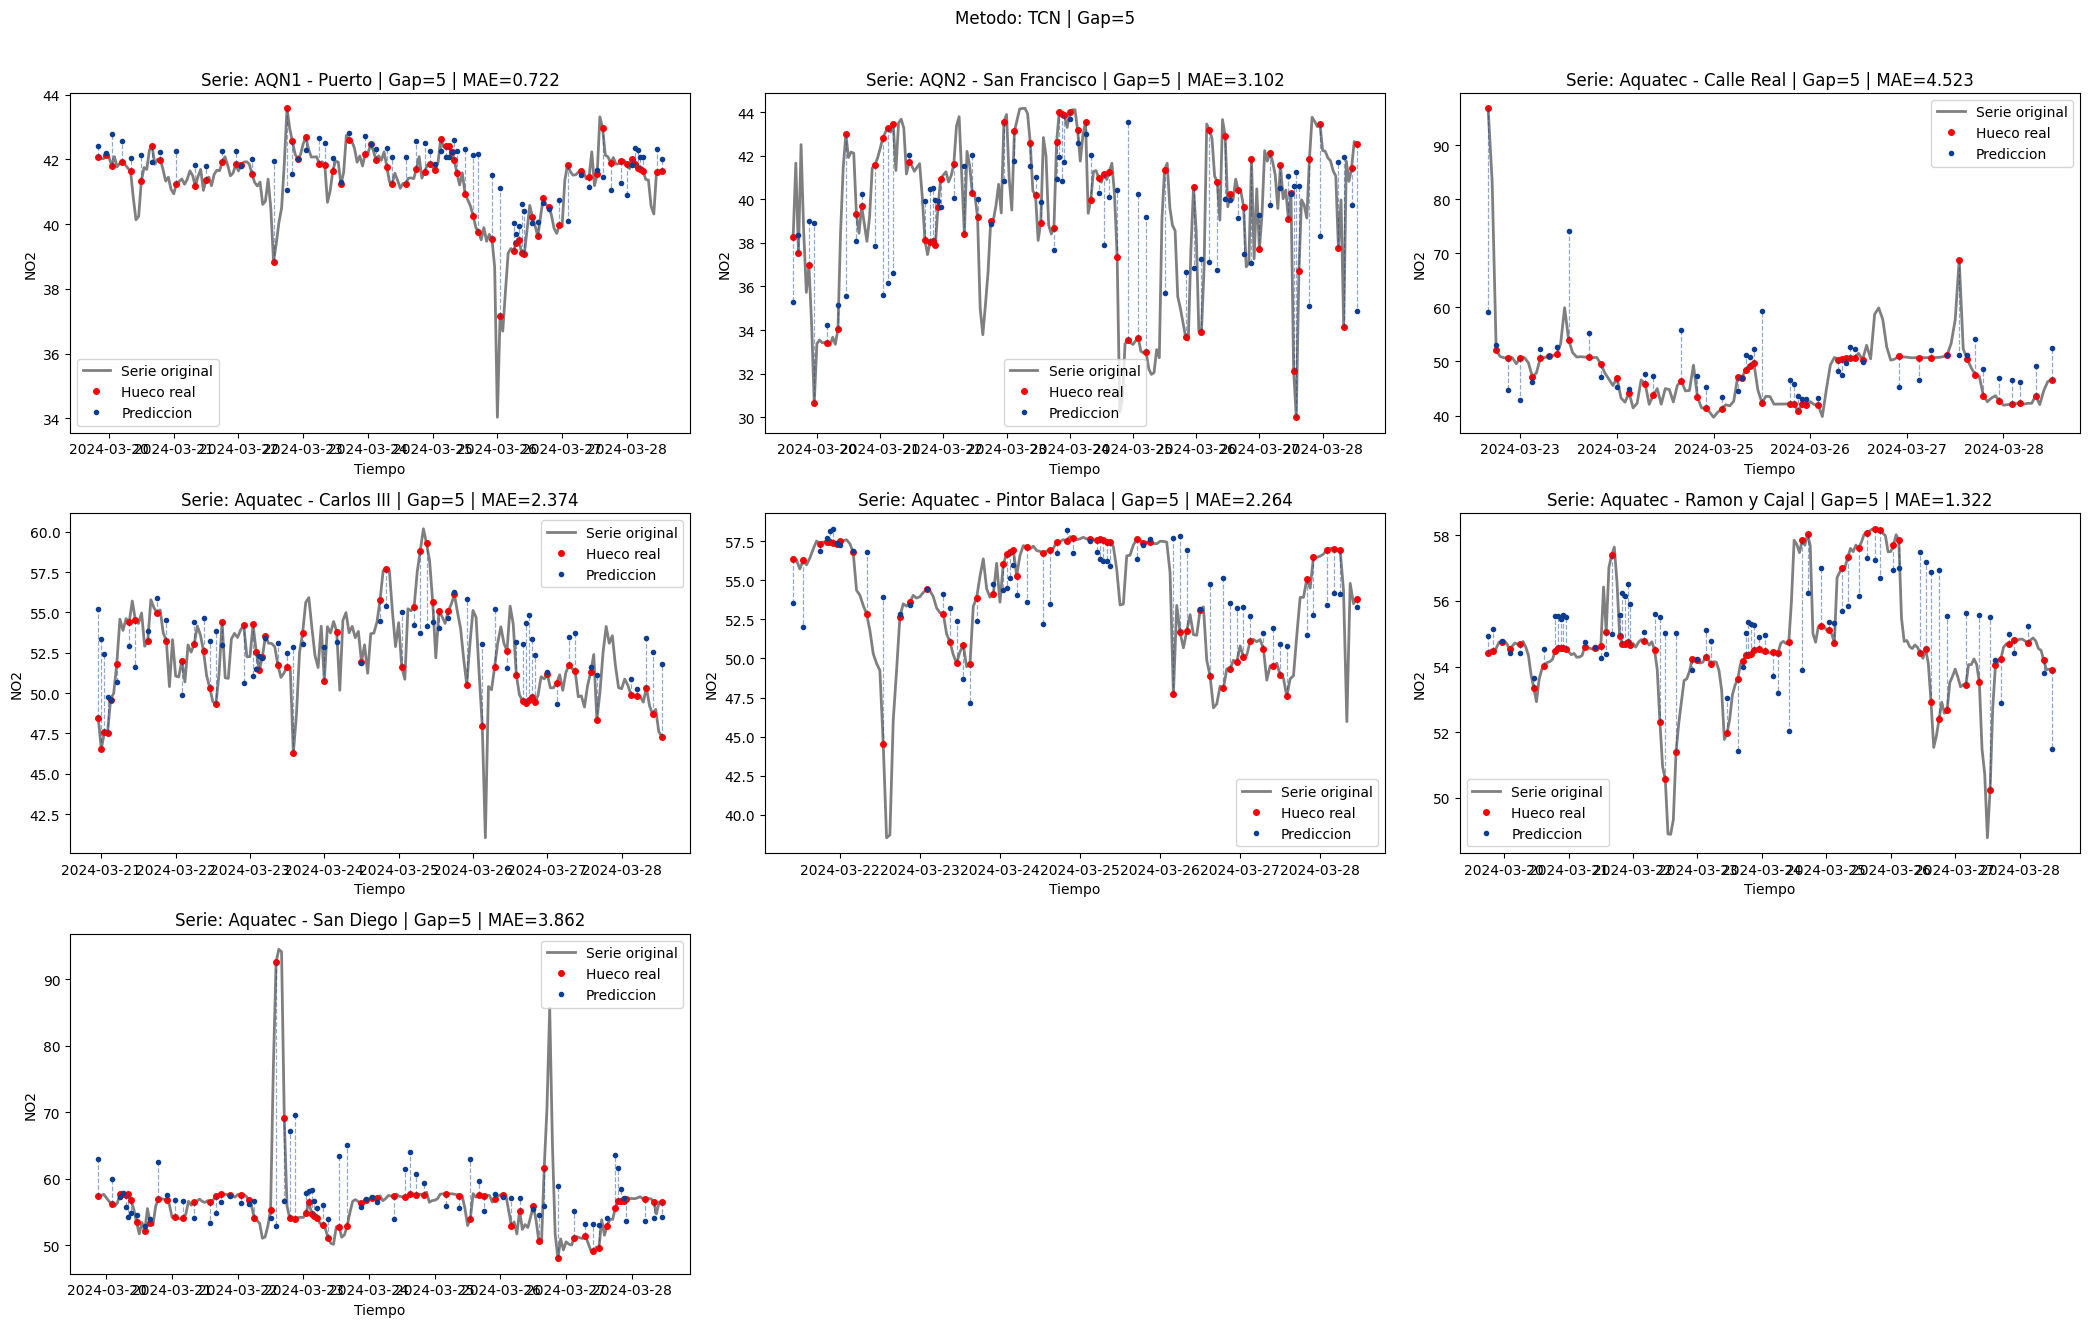

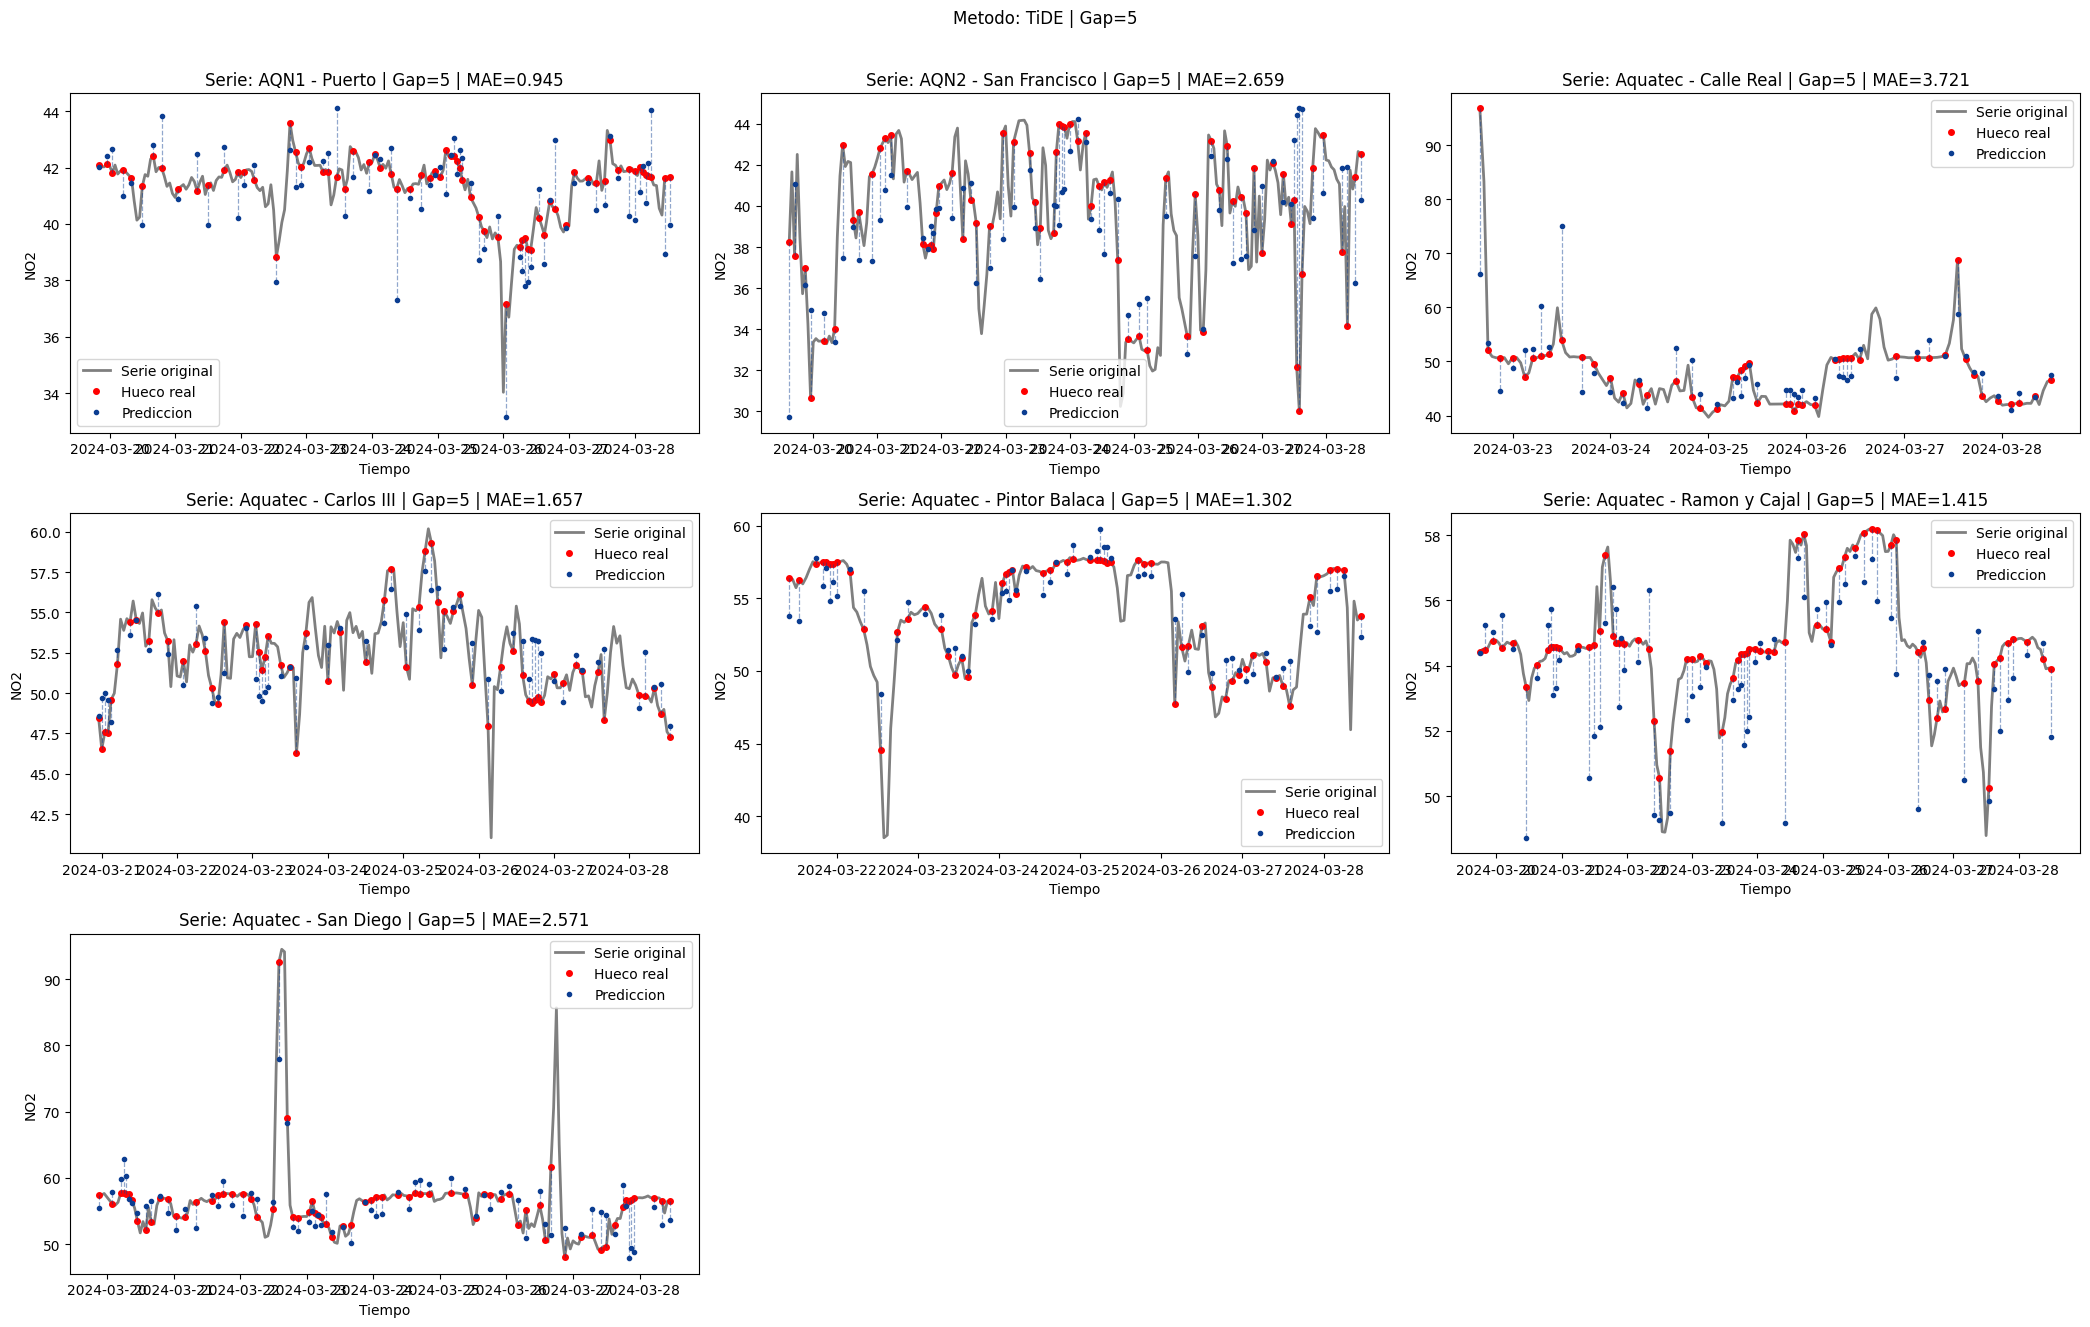

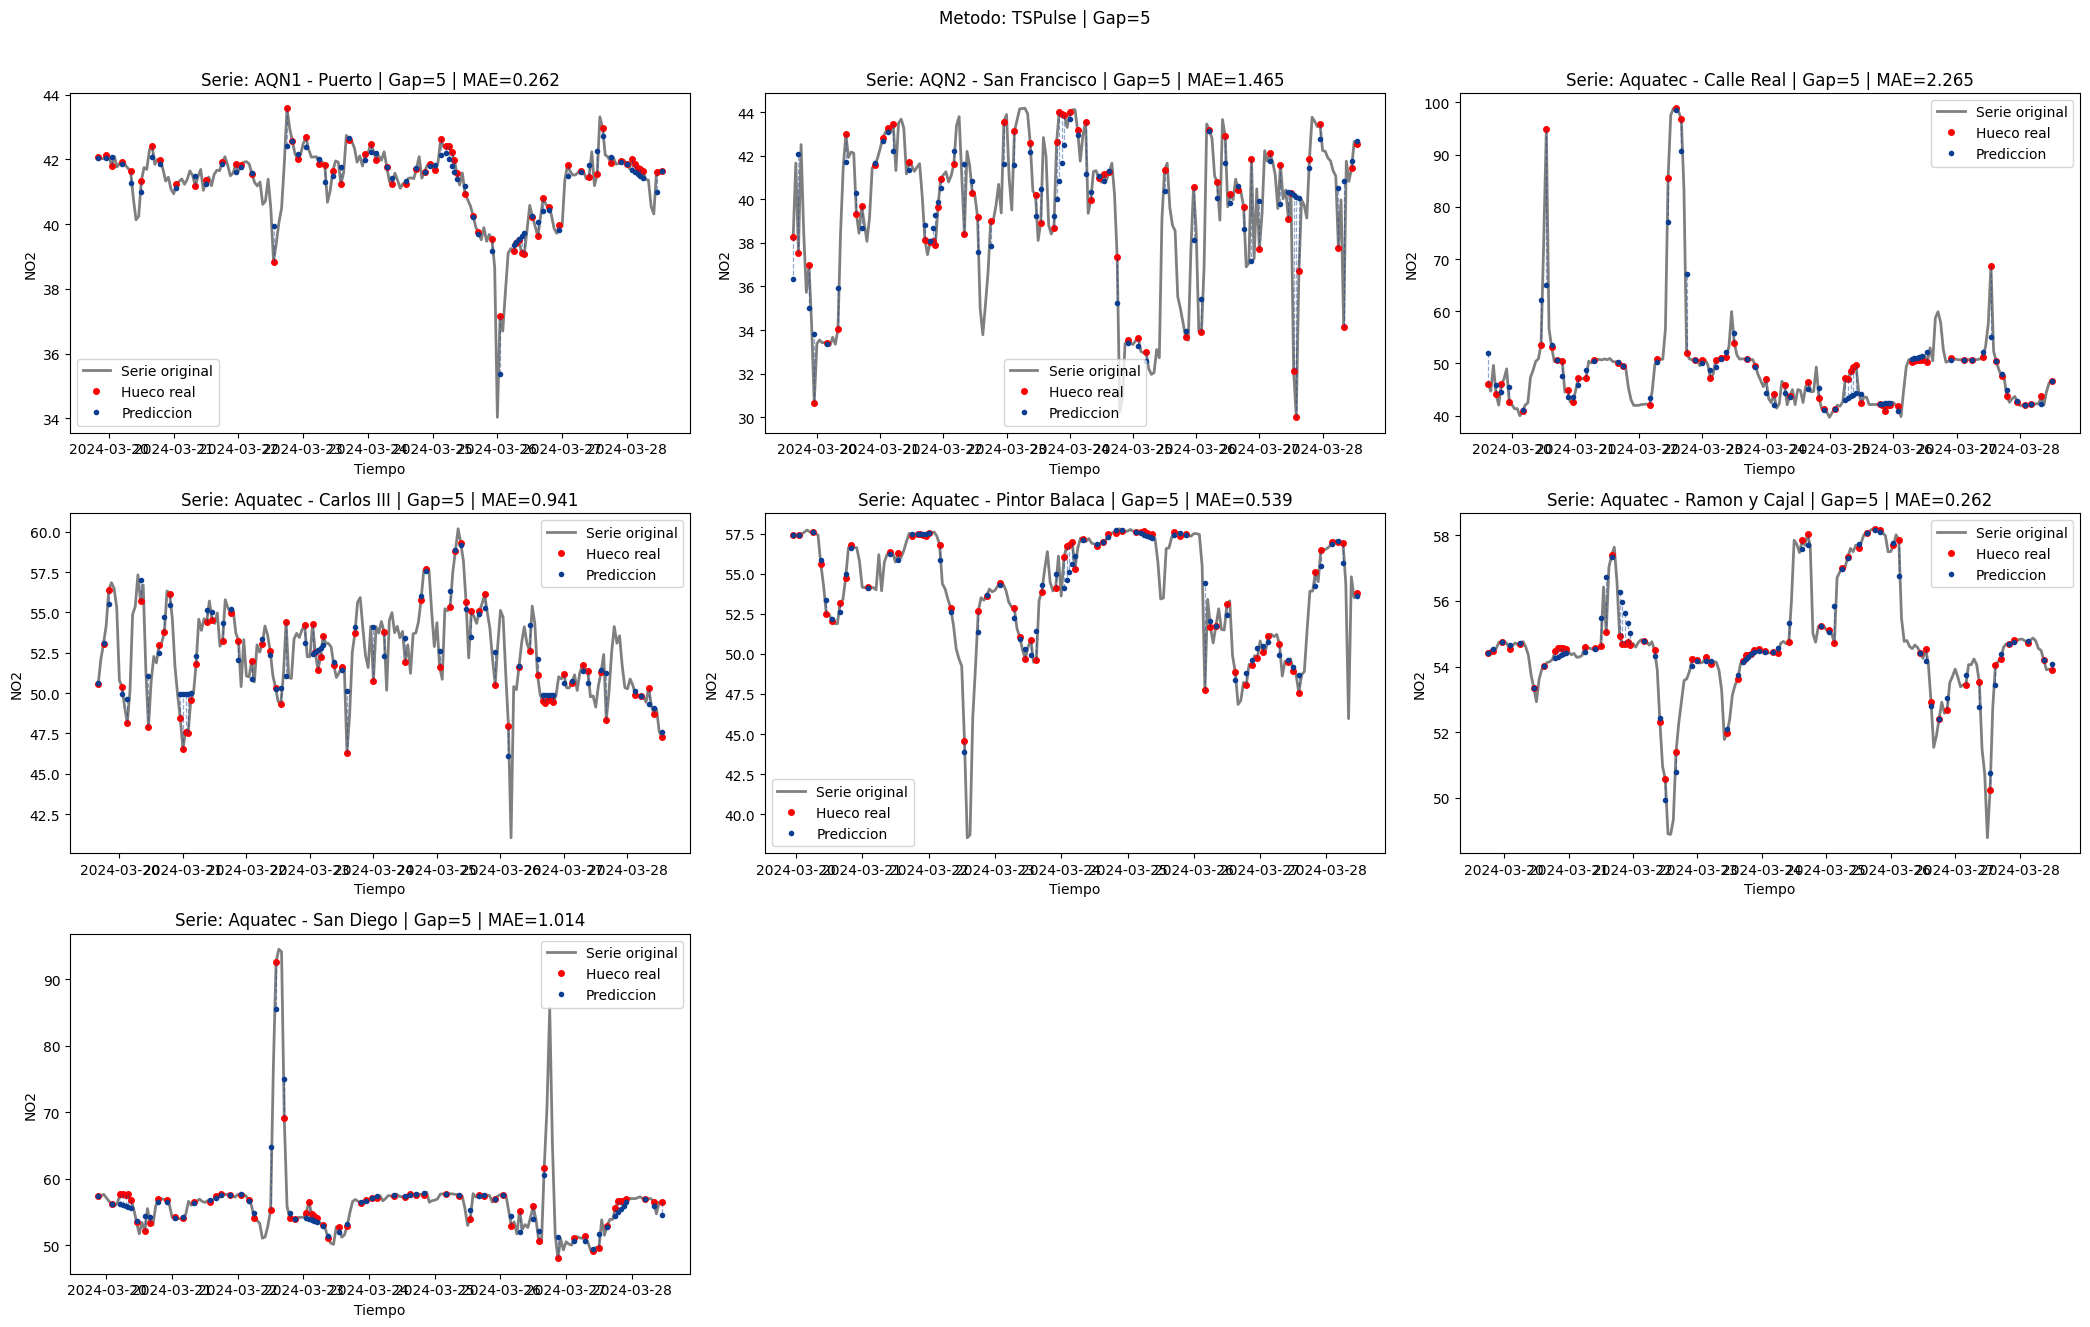

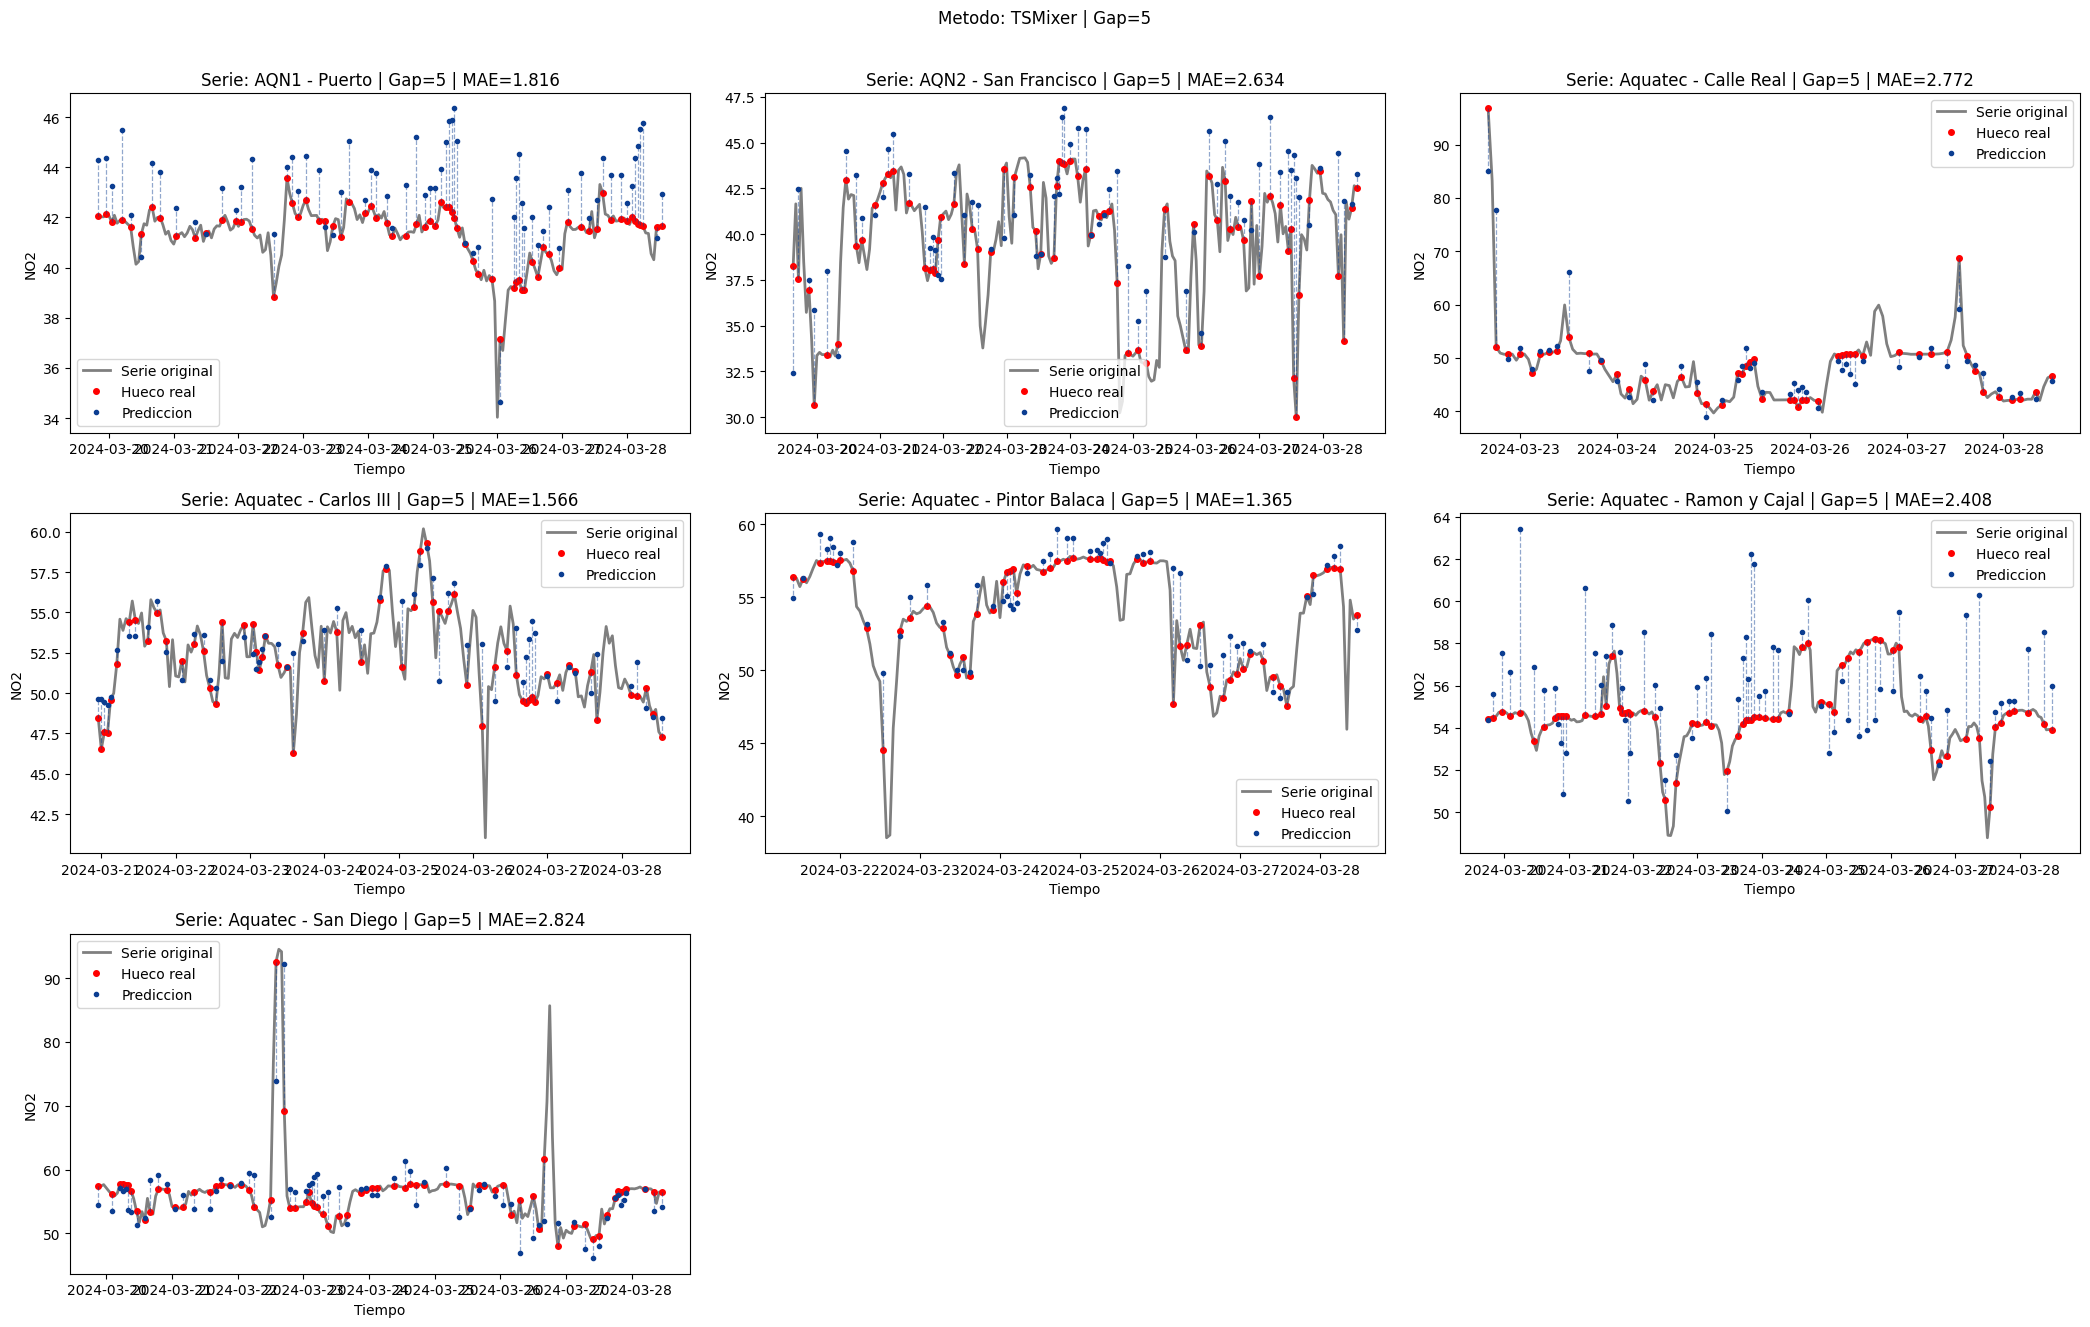

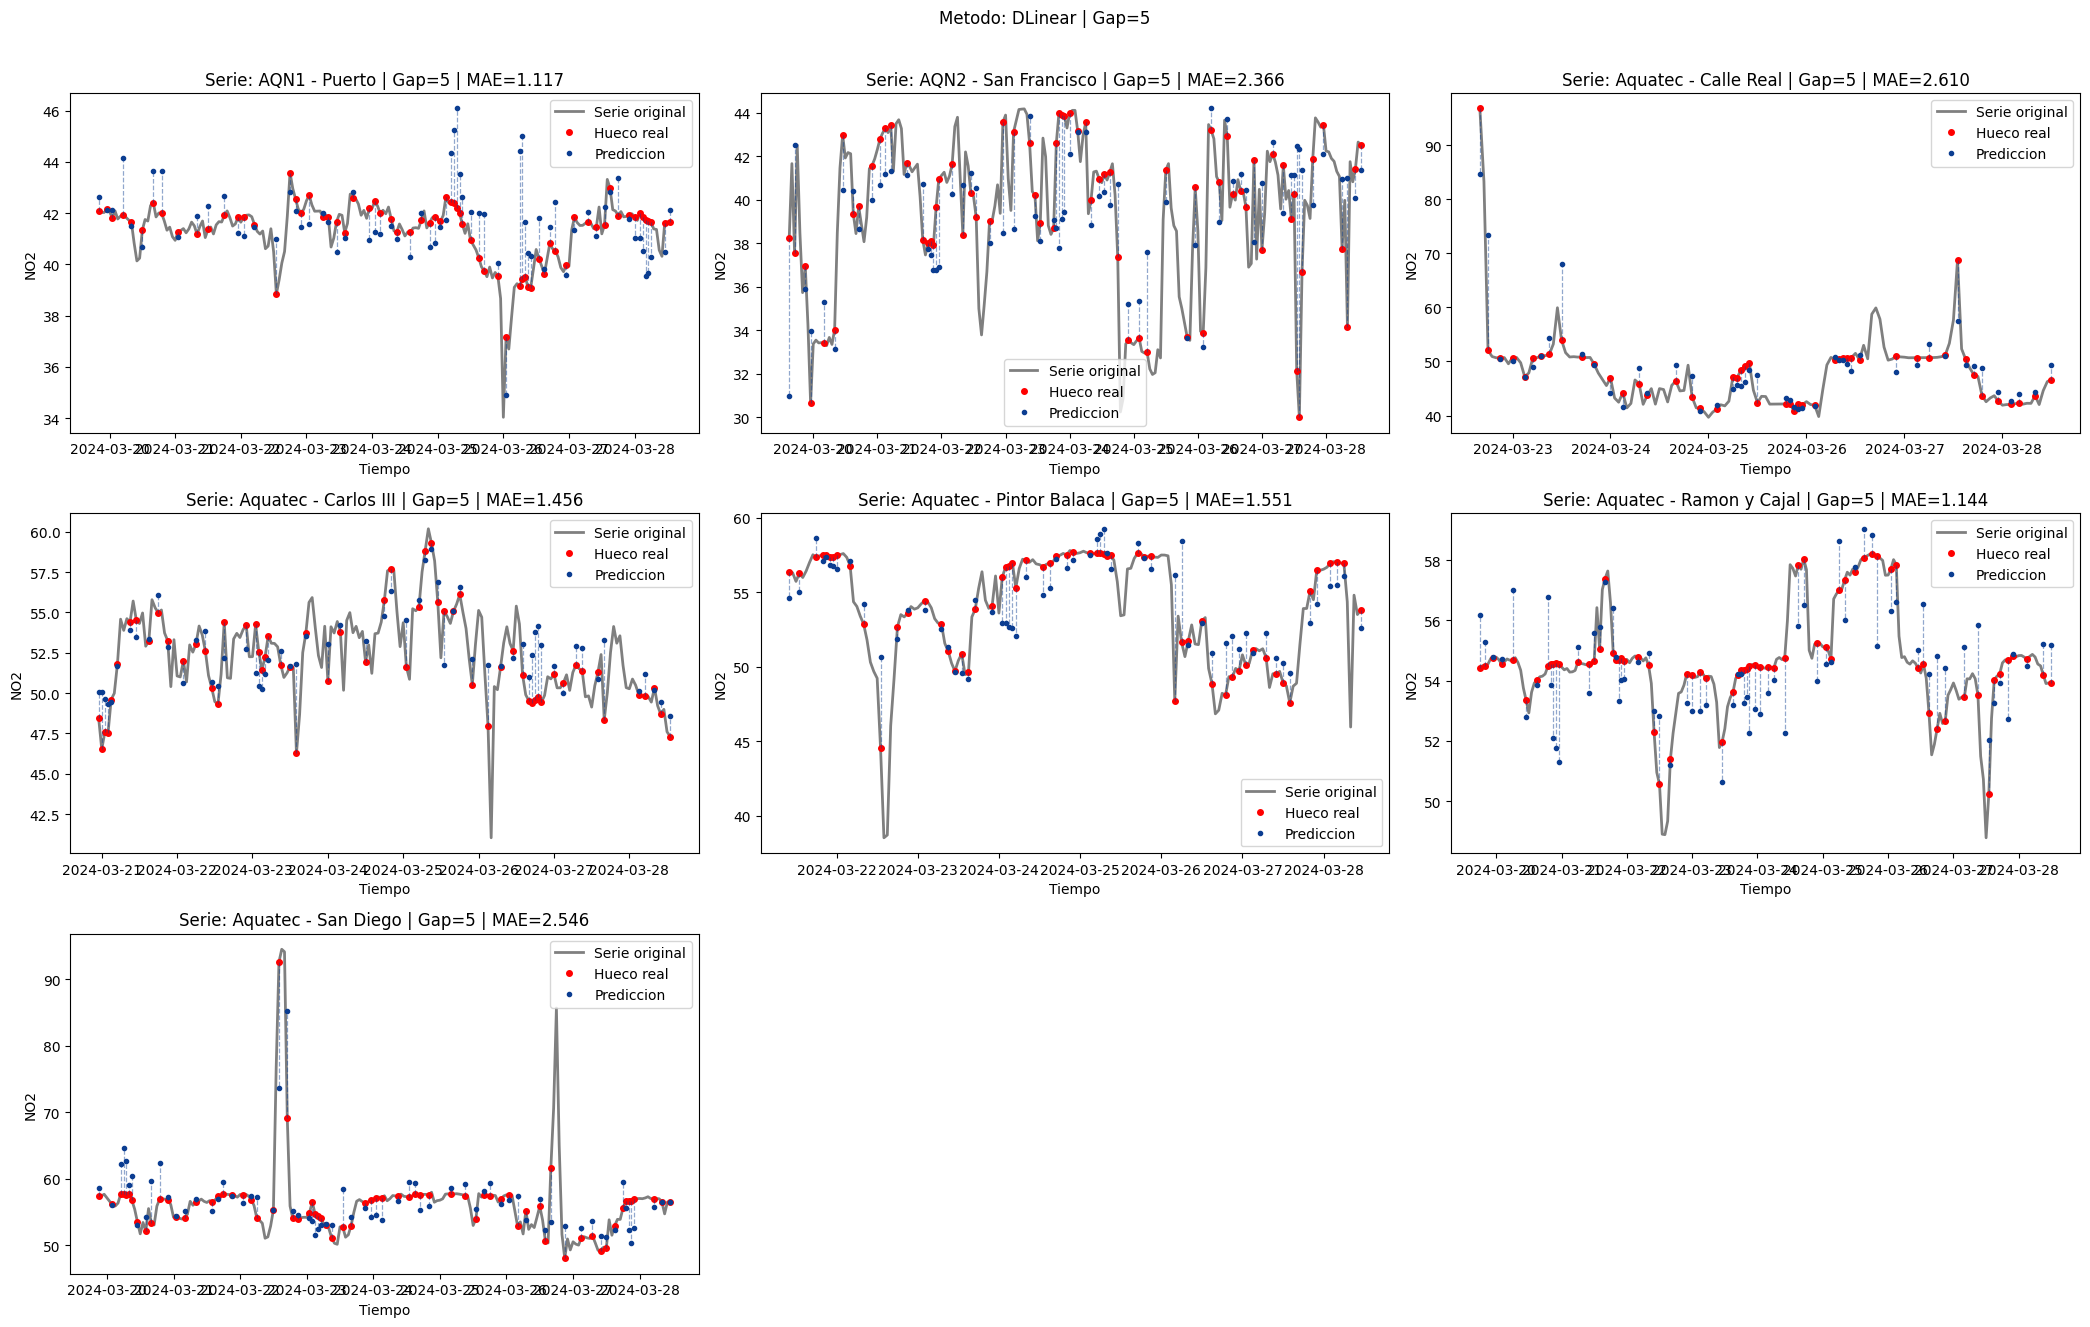

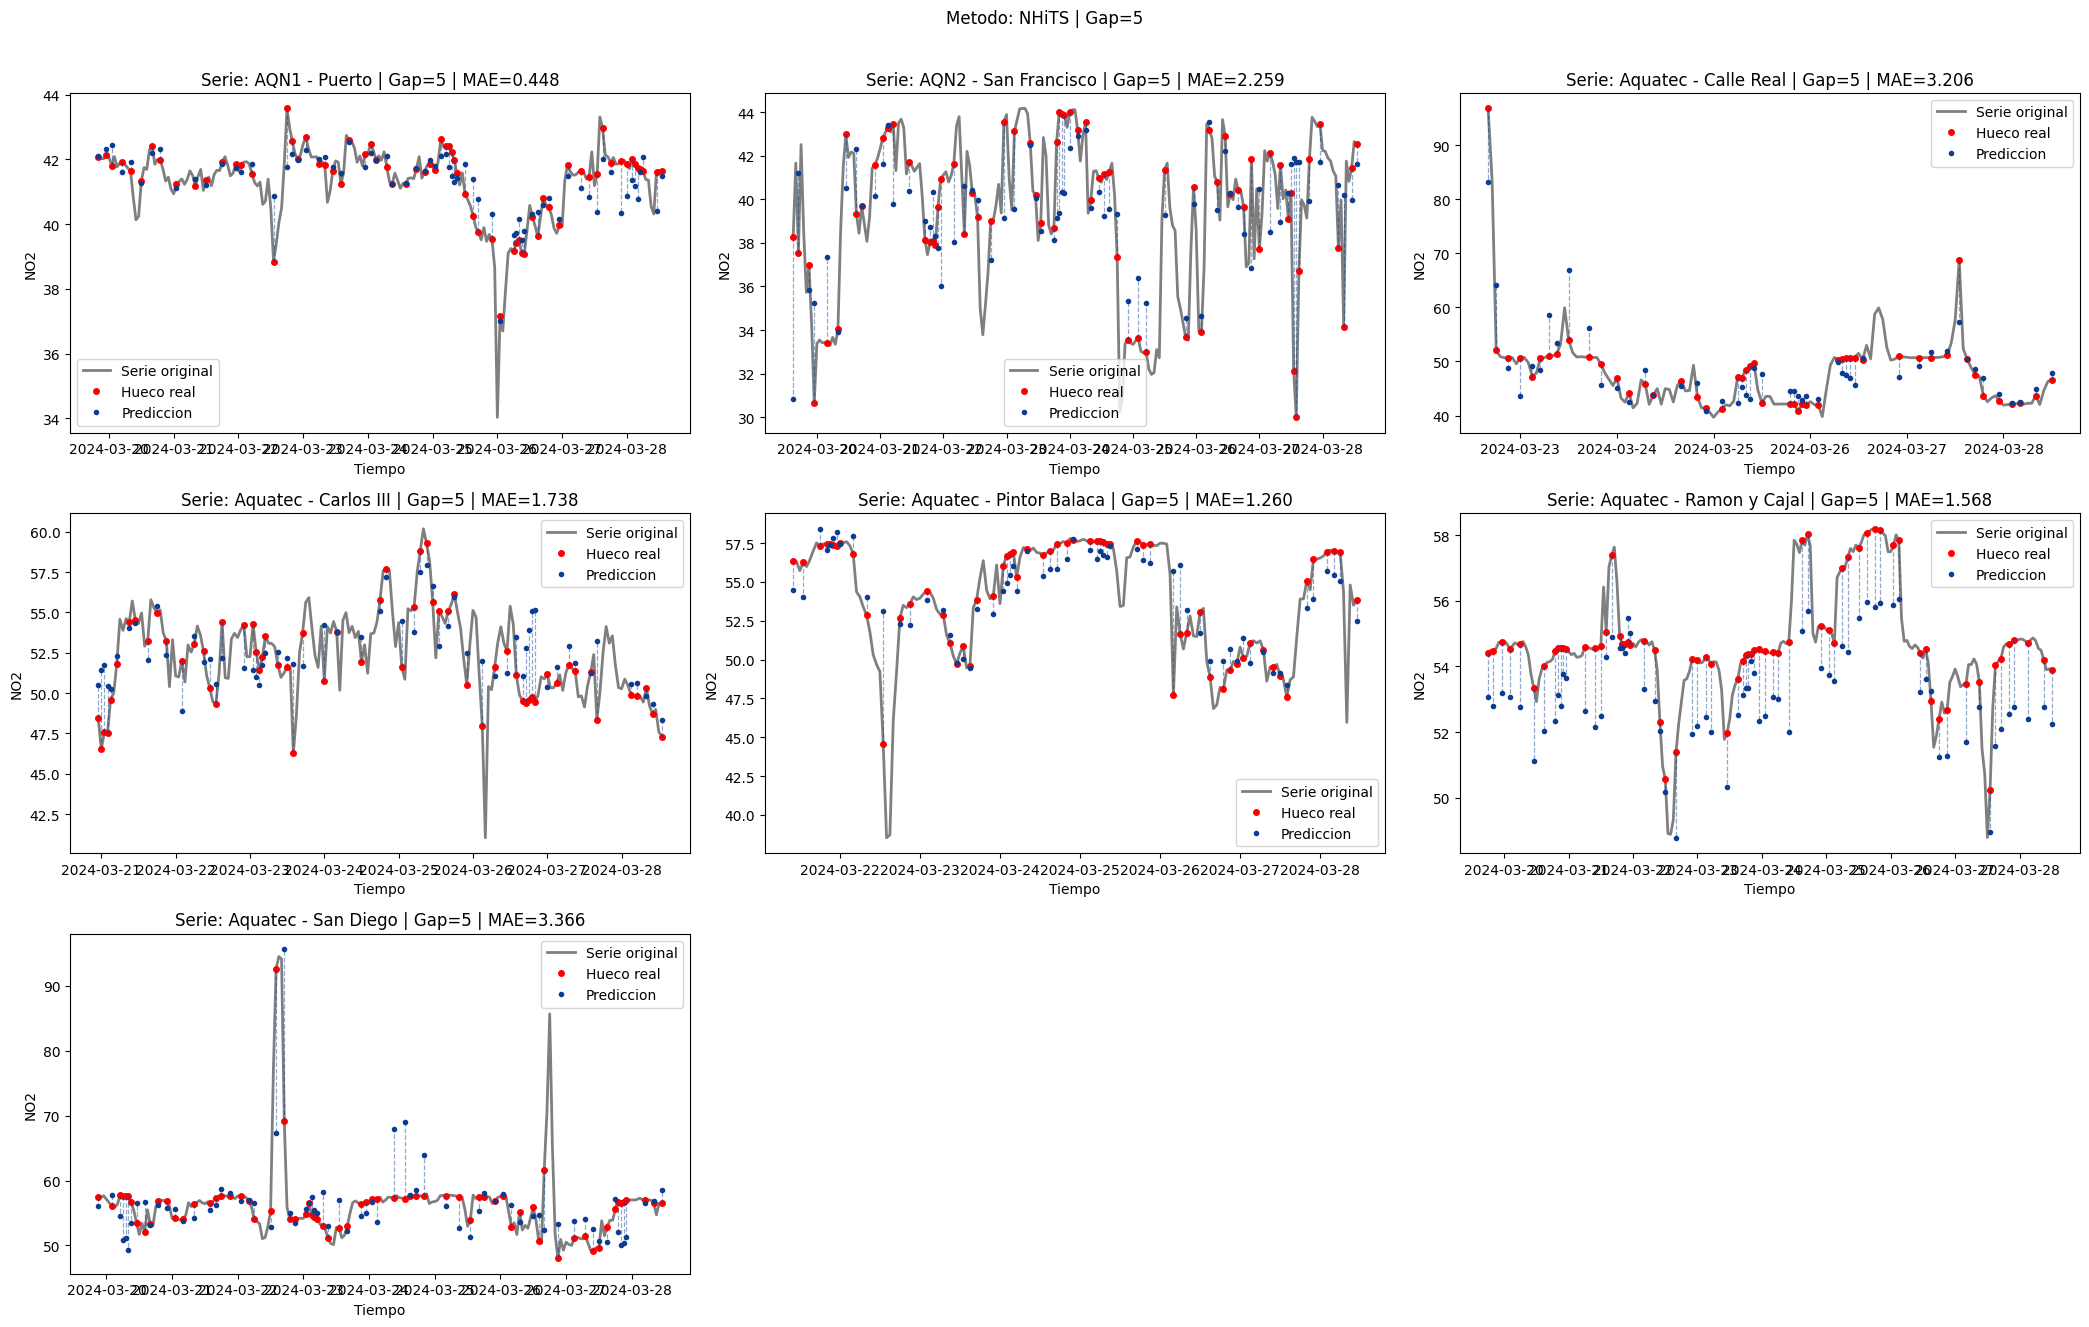

In [6]:
import sys
from pathlib import Path
# Si tu notebook está en la raíz del repo
sys.path.insert(0, str((Path.cwd() / "src").resolve()))
from airquality.visualizations.plotting import plot_predictions_by_method_grid
plot_predictions_by_method_grid(
    plot_store=plot_store,   # el que devuelve tu pipeline
    series_name="all",       # todas las series
    methods=None,            # todos los modelos
    gaps=None,               # todos los gaps (si aplica)
    grid_n_cols=3,
    grid_cell_width=7.0,
    grid_cell_height=4.5,
    render_style="mixed",    # serie real en línea + predicciones en puntos
)

In [7]:
import sys
from pathlib import Path
# Si ejecutas desde la raíz del repo:
sys.path.insert(0, str((Path.cwd() / "src").resolve()))
from airquality.imputation.run_benchmark import run_imputation_benchmark_parallel_montecarlo
results_mc_df, summary_mc_df, ranking_by_seed_df = run_imputation_benchmark_parallel_montecarlo(
    size_k=5,
    model_names=("TiDE", "NHiTS", "TCN", "TSMixer", "RNN", "NLinear", "DLinear", "TSPulse"),
    force_cpu=True,                  # pon False si quieres usar GPU
    gap_sizes=(2, 5),
    num_gaps=15,
    gap_strategy="hybrid_tspulse",
    metrics=("mae", "rmse", "mase"),
    seasonality_m=24,
    freq="h",
    max_workers=4,
    n_runs=20,
    seed_start=42,
    seed_step=30,
    progress=True,
)


[MonteCarlo] 1/20 con seed=42
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=2: 18 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=5: 41 gaps sin contexto minimo. Motivos: ['No se alcanza el contexto minimo del modelo incluso completando con train; se deja NaN en ese gap.']
[execute_complete_pipeline] Gap=5: 41 gaps sin contexto minimo. Motivos: ['No se alcanza e

In [8]:
print("=== Resumen Monte Carlo ===")
print(summary_mc_df)
display(ranking_by_seed_df.head())
display(results_mc_df.head())

=== Resumen Monte Carlo ===
    Modelo  Runs  MAE_Mean   MAE_Std   MAE_P05   MAE_P95  RMSE_Mean  RMSE_Std  \
0  TSPulse    20  0.899703  0.090250  0.796811  1.067429   1.616497  0.216826   
1  NLinear    20  1.692533  0.125486  1.542367  1.855050   2.447900  0.256003   
2  DLinear    20  1.749139  0.117950  1.613450  1.910960   2.505434  0.247080   
3    NHiTS    20  1.922340  0.120072  1.767537  2.134836   2.726151  0.263746   
4      RNN    20  2.028927  0.115284  1.872451  2.208707   2.995869  0.257452   
5     TiDE    20  2.099397  0.120700  1.916647  2.272120   2.984447  0.210203   
6      TCN    20  2.806377  0.151019  2.589172  2.992072   4.058205  0.273398   
7  TSMixer    20  2.182913  0.115131  2.037946  2.343791   3.009564  0.256085   

   RMSE_P05  RMSE_P95  MASE_Mean  MASE_Std  MASE_P05  MASE_P95  
0  1.299731  2.041510   0.284055  0.019771  0.258487  0.313515  
1  2.111400  2.787719   0.589138  0.035315  0.541596  0.641320  
2  2.200843  2.805207   0.620448  0.033676  0.5

,Seed,MonteCarlo_Run,Modelo,MAE,RMSE,MASE
0,42,1,DLinear,1.792448,2.528379,0.668532
1,42,1,NHiTS,2.037002,2.978535,0.678406
2,42,1,NLinear,1.703536,2.463014,0.627243
3,42,1,RNN,2.164714,3.226150,0.750302
4,42,1,TCN,2.892604,4.279959,0.934010


,Modelo,Serie,Gap_Size,MAE,RMSE,MASE,Seed,MonteCarlo_Run
0,TiDE,AQN1 - Puerto,2,1.029562,1.441914,0.928202,42,1
1,TiDE,AQN2 - San Francisco,2,2.564083,3.388744,0.804498,42,1
2,TiDE,Aquatec - Calle Real,2,4.269781,5.820127,0.743308,42,1
3,TiDE,Aquatec - Carlos III,2,1.326181,1.715140,0.513774,42,1
4,TiDE,Aquatec - Pintor Balaca,2,1.409480,2.012757,0.573704,42,1


Probar transferlearning. 